In [ ]:
import kagglehub
path = kagglehub.dataset_download("mmumairkhattak/hospital-patient-records-dataset-2026-healthcare")

Using Colab cache for faster access to the 'hospital-patient-records-dataset-2026-healthcare' dataset.


In [ ]:
import pandas as pd
import os

hospital_data_path = os.path.join(path, 'hospital_patient_records_dataset.csv')
hospital_df = pd.read_csv(hospital_data_path)

In [ ]:
display(hospital_df.head())

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Smoking_Status,Alcohol_Consumption,Exercise_Frequency,...,Heart_Rate,Treatment_Cost,Insurance_Coverage,Doctor_Experience_Years,Hospital_Rating,Follow_Up_Required,Recovery_Days,Readmission_Risk,Treatment_Outcome,Patient_Satisfaction
0,400001,54,Female,O-,162.6,61.4,23.22,Never,Low,NaN,...,95,2991.35,Partial,20,3.71,No,7,Low,Recovered,3.76
1,400002,53,Female,A+,161.2,62.9,24.21,Never,Moderate,Low,...,99,5379.29,NaN,14,3.82,Yes,53,High,Stable,3.80
2,400003,29,Male,B-,164.8,79.1,29.12,Former,NaN,Low,...,104,8284.91,Partial,4,4.15,Yes,36,Medium,Recovered,3.95
3,400004,49,Female,O+,174.0,64.4,21.27,Current,High,Low,...,72,3760.59,Partial,1,4.32,Yes,22,Medium,Recovered,4.83
4,400005,39,Male,O+,162.0,58.8,22.41,Never,Moderate,Low,...,45,12054.09,Partial,15,4.29,Yes,72,High,Stable,3.71


In [ ]:
missing_values = hospital_df.isnull().sum()
display(missing_values[missing_values > 0])

,0
Alcohol_Consumption,7614
Exercise_Frequency,4816
Insurance_Coverage,3551


In [ ]:
# Identify categorical columns
categorical_cols = hospital_df.select_dtypes(include='object').columns

print("Distributions of Categorical Variables:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(hospital_df[col].value_counts())


Distributions of Categorical Variables:

--- Gender ---


,count
Gender,
Female,10331
Male,9669



--- Blood_Group ---


,count
Blood_Group,
O+,2579
AB+,2562
B-,2541
B+,2529
O-,2473
AB-,2459
A+,2456
A-,2401



--- Smoking_Status ---


...

,count
Follow_Up_Required,
Yes,15944
No,4056



--- Readmission_Risk ---


,count
Readmission_Risk,
Medium,9886
High,5735
Low,4379



--- Treatment_Outcome ---


,count
Treatment_Outcome,
Recovered,12486
Stable,6322
Poor,1192


Detecting Outliers in Numerical Variables (Box Plots):


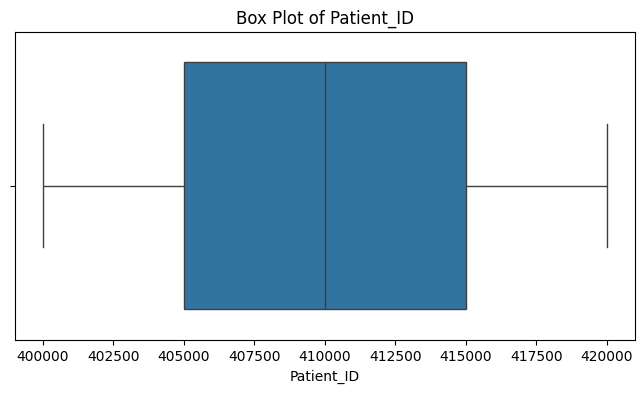

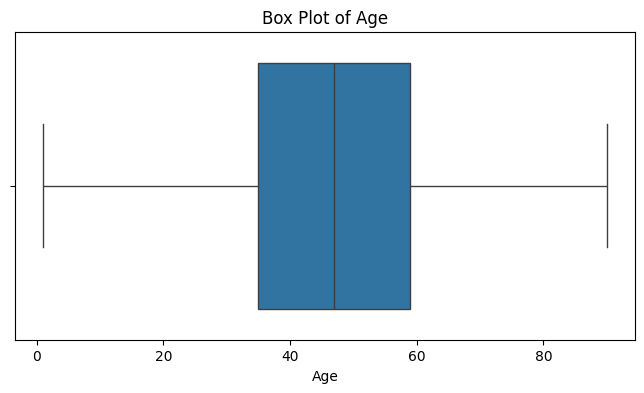

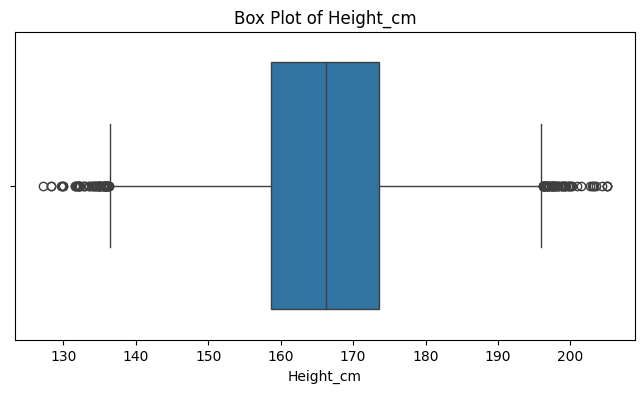

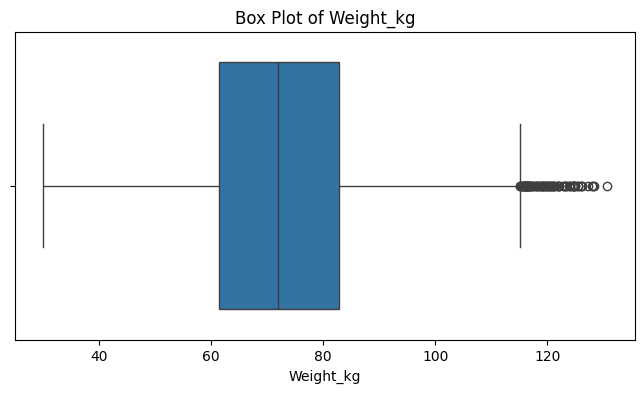

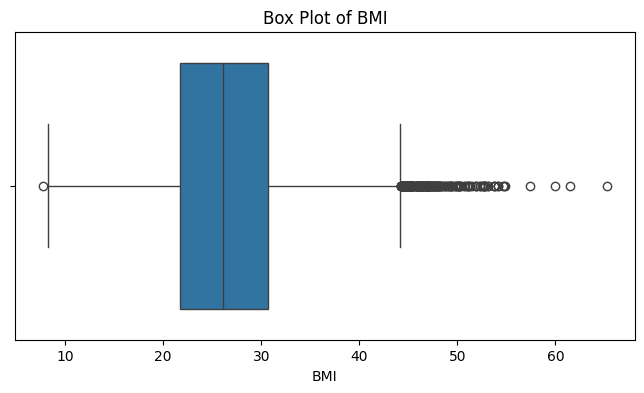

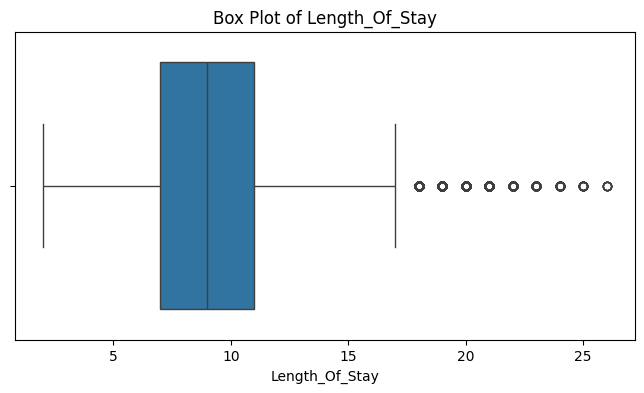

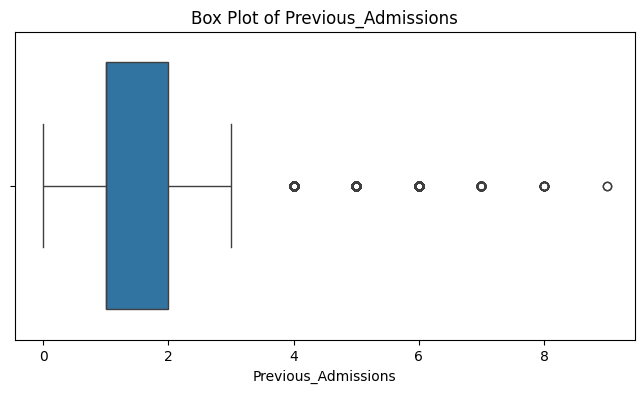

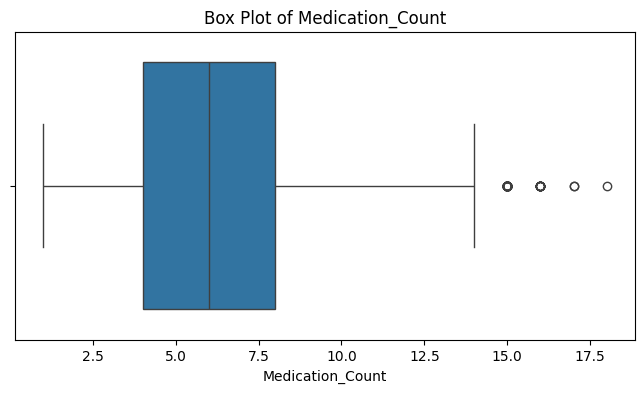

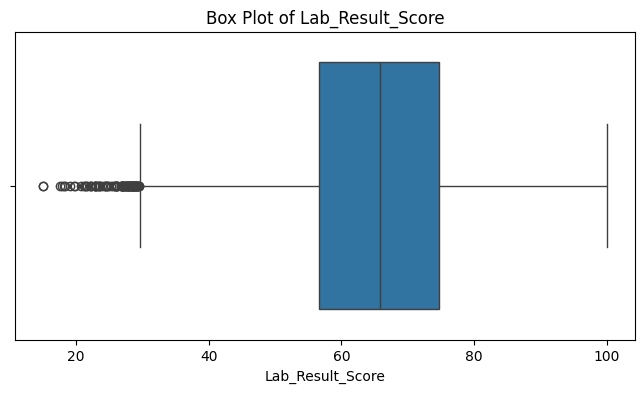

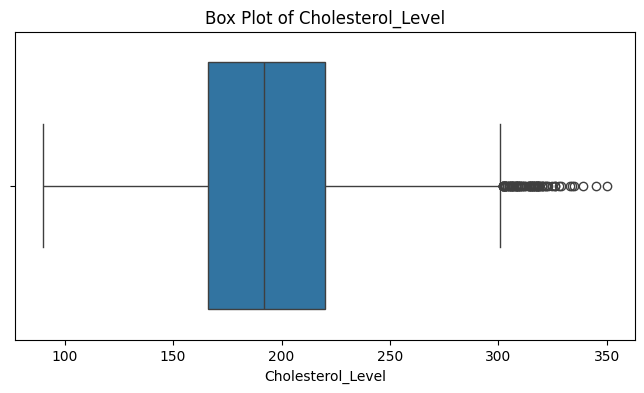

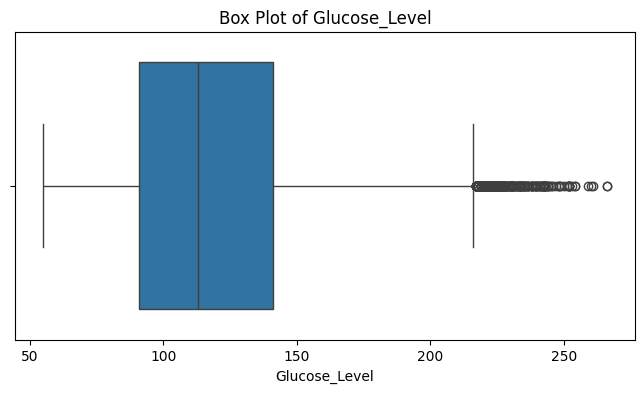

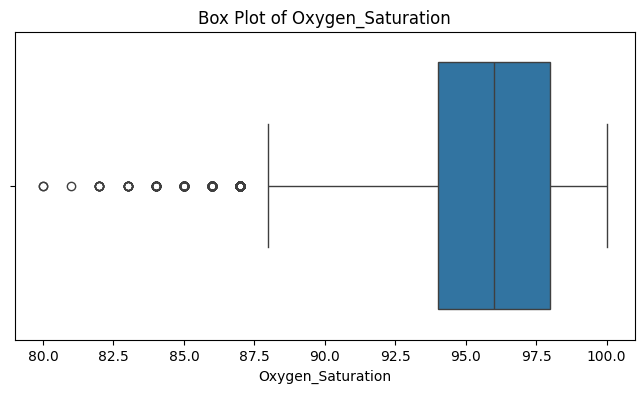

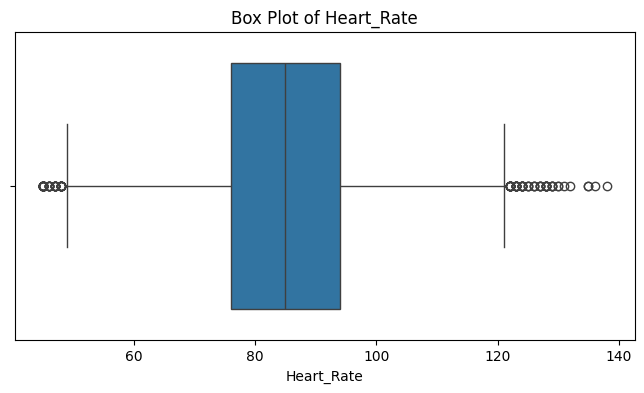

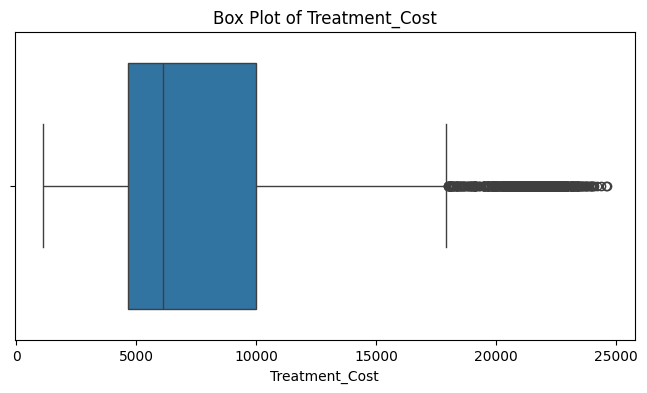

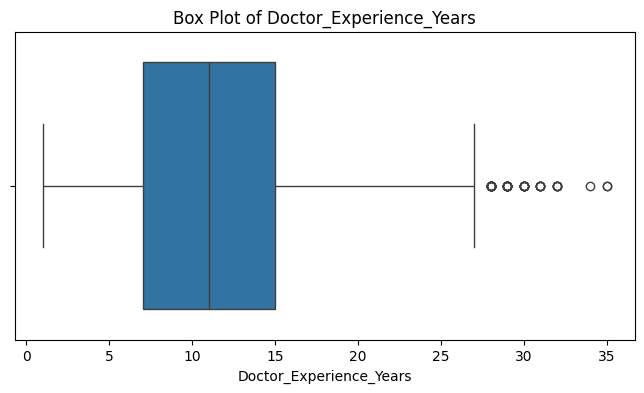

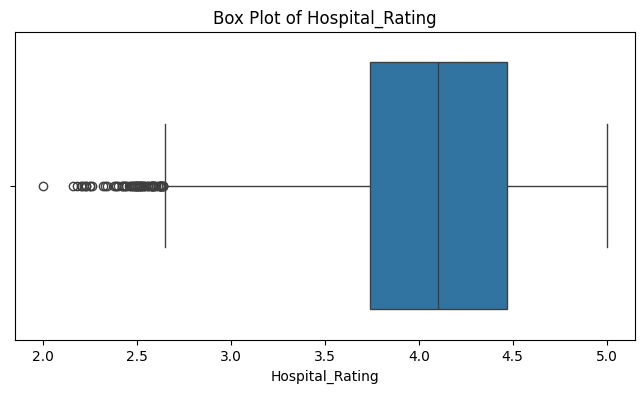

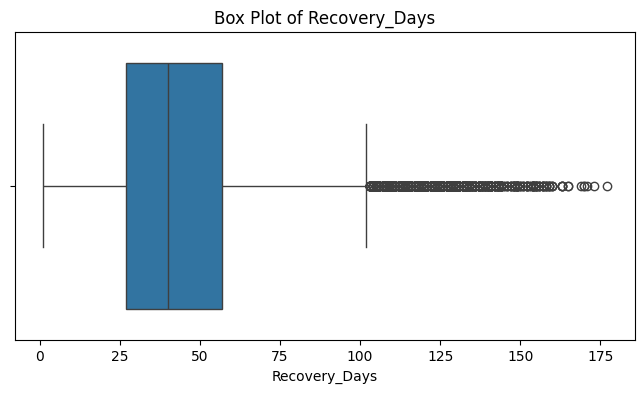

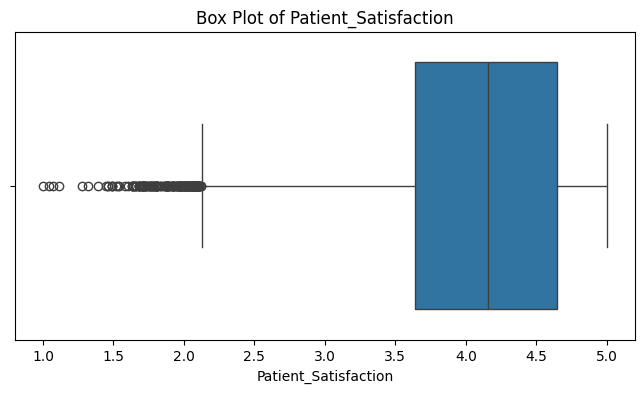

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols = hospital_df.select_dtypes(include=['int64', 'float64']).columns

print("Detecting Outliers in Numerical Variables (Box Plots):")

# Create box plots for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=hospital_df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

### Identifying Class Imbalance

Class imbalance occurs when the number of observations belonging to one class is significantly lower than those belonging to other classes. This can be problematic for machine learning models, as they might become biased towards the majority class.

Let's check for class imbalance in relevant categorical columns such as `Treatment_Outcome` and `Readmission_Risk`.

In [ ]:
# Check for class imbalance in 'Treatment_Outcome'
print('Class distribution for Treatment_Outcome:')
display(hospital_df['Treatment_Outcome'].value_counts())
display(hospital_df['Treatment_Outcome'].value_counts(normalize=True) * 100)

# Check for class imbalance in 'Readmission_Risk'
print('\nClass distribution for Readmission_Risk:')
display(hospital_df['Readmission_Risk'].value_counts())
display(hospital_df['Readmission_Risk'].value_counts(normalize=True) * 100)

Class distribution for Treatment_Outcome:


,count
Treatment_Outcome,
Recovered,12486
Stable,6322
Poor,1192


,proportion
Treatment_Outcome,
Recovered,62.43
Stable,31.61
Poor,5.96



Class distribution for Readmission_Risk:


,count
Readmission_Risk,
Medium,9886
High,5735
Low,4379


,proportion
Readmission_Risk,
Medium,49.430
High,28.675
Low,21.895


### Examining Feature Relationships

Understanding the relationships between features is crucial for feature selection, engineering, and model building. We'll start by looking at the correlation between numerical features.

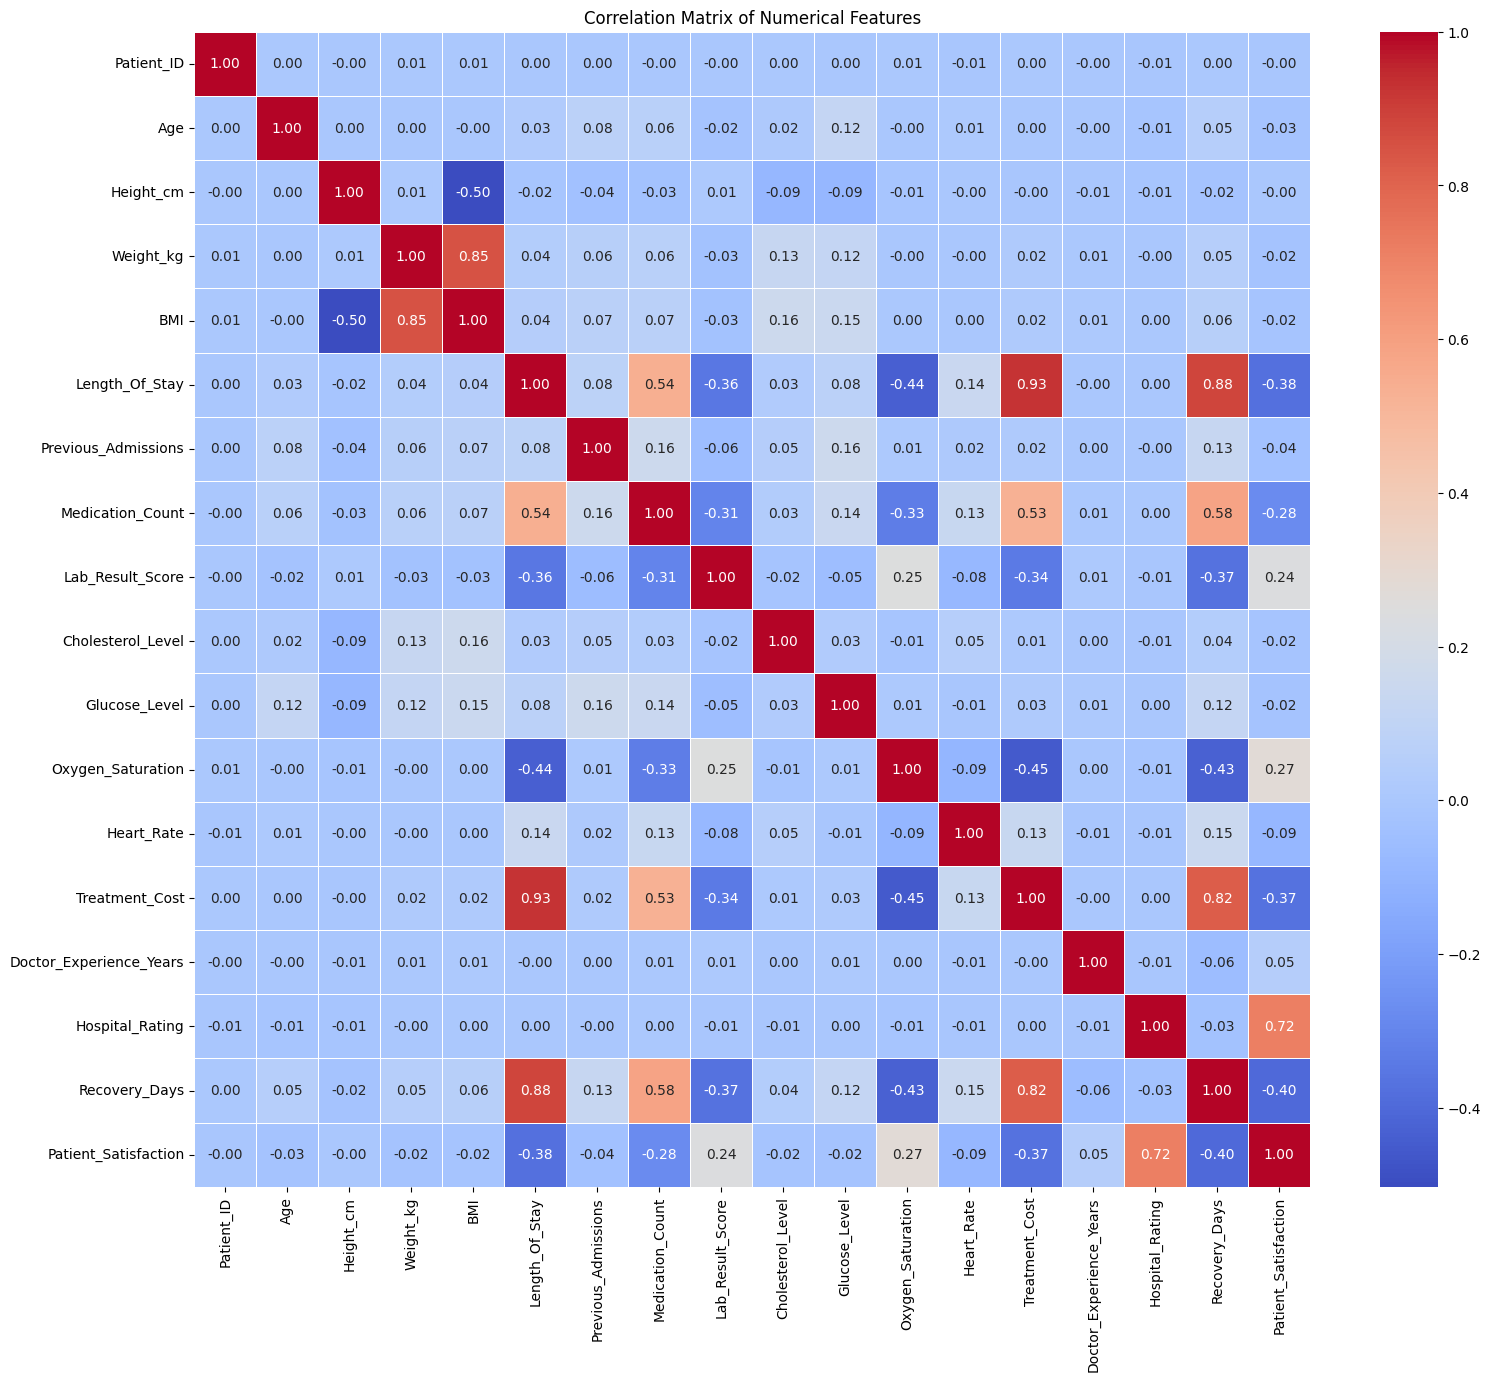

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = hospital_df.select_dtypes(include=['int64', 'float64']).columns
numerical_df = hospital_df[numerical_cols]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

This heatmap shows the pairwise linear correlation coefficients between all numerical features. Values closer to 1 or -1 indicate a strong positive or negative linear relationship, respectively, while values closer to 0 indicate a weak linear relationship.

After reviewing the correlation among numerical features, would you like to:
1.  Investigate relationships between specific categorical features (e.g., `Gender` and `Smoking_Status`)?
2.  Examine relationships between numerical and categorical features (e.g., `Age` and `Treatment_Outcome`)?
3.  Focus on specific highly correlated features?

### Data Cleaning: Removing Duplicate Rows

Duplicate rows can distort analysis and model training. It's a good practice to check for and remove them to ensure data integrity.

In [ ]:
# Check for duplicate rows
duplicate_rows = hospital_df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    hospital_df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {hospital_df.shape[0]}")
else:
    print("No duplicate rows found.")

# Verify no more duplicates exist
print(f"\nNumber of duplicate rows after removal: {hospital_df.duplicated().sum()}")

Number of duplicate rows found: 0
No duplicate rows found.

Number of duplicate rows after removal: 0


The duplicate rows (if any) have now been removed from the `hospital_df`. This ensures that each observation in our dataset is unique.

What other data cleaning steps would you like to perform next?

1.  **Data Type Conversion:** Ensure all columns have appropriate data types.
2.  **Feature Engineering:** Create new features from existing ones.
3.  **Handling Outliers:** Decide on a strategy to handle the outliers we identified earlier (e.g., capping, removal, transformation).
4.  **Encoding Categorical Variables:** Prepare categorical features for modeling (e.g., One-Hot Encoding, Label Encoding).

In [ ]:
print(hospital_df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Blood_Group', 'Height_cm', 'Weight_kg', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency', 'Chronic_Disease', 'Diabetes', 'Hypertension', 'Heart_Disease', 'Admission_Type', 'Department', 'Diagnosis', 'Severity_Level', 'Length_Of_Stay', 'Previous_Admissions', 'Surgery_Performed', 'ICU_Admission', 'Medication_Count', 'Lab_Result_Score', 'Blood_Pressure', 'Cholesterol_Level', 'Glucose_Level', 'Oxygen_Saturation', 'Heart_Rate', 'Treatment_Cost', 'Insurance_Coverage', 'Doctor_Experience_Years', 'Hospital_Rating', 'Follow_Up_Required', 'Recovery_Days', 'Readmission_Risk', 'Treatment_Outcome', 'Patient_Satisfaction']


### Feature Engineering: Creating Age Groups

Categorizing age can sometimes provide more meaningful insights and better model performance than using raw age, especially if the relationship between age and the target variable is not linear. We will create `Age_Group` bins.

In [ ]:
# Define age bins and labels
age_bins = [0, 18, 35, 50, 65, 100]
age_labels = ['Child', 'Young Adult', 'Adult', 'Middle-Aged', 'Senior']

hospital_df['Age_Group'] = pd.cut(hospital_df['Age'], bins=age_bins, labels=age_labels, right=False)

print("Distribution of new 'Age_Group' feature:")
display(hospital_df['Age_Group'].value_counts())

Distribution of new 'Age_Group' feature:


,count
Age_Group,
Adult,6362
Middle-Aged,5541
Young Adult,3802
Senior,3273
Child,1022


### Feature Engineering: Creating BMI Categories

Similar to age, categorizing BMI can provide a more interpretable way to analyze patient health status and identify risk groups. We will create `BMI_Category` bins.

In [ ]:
# Define BMI bins and labels based on standard health categories
bmi_bins = [0, 18.5, 24.9, 29.9, 34.9, 39.9, 100]
bmi_labels = ['Underweight', 'Normal weight', 'Overweight', 'Obesity (Class I)', 'Obesity (Class II)', 'Obesity (Class III)']

hospital_df['BMI_Category'] = pd.cut(hospital_df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

print("Distribution of new 'BMI_Category' feature:")
display(hospital_df['BMI_Category'].value_counts())

Distribution of new 'BMI_Category' feature:


,count
BMI_Category,
Normal weight,6327
Overweight,5625
Obesity (Class I),3472
Underweight,2303
Obesity (Class II),1577
Obesity (Class III),696


### Feature Engineering: Creating Chronic Disease Count

To capture the overall health status related to chronic conditions, we can create a composite feature called `Chronic_Disease_Count`. This feature will sum the binary indicators of various chronic diseases, providing a numerical representation of how many chronic diseases a patient has.

In [ ]:
# Convert 'Chronic_Disease' to a binary (0/1) format if it's 'Yes'/'No'
# Assuming 'Chronic_Disease' is 'Yes' for presence and 'No' for absence.
if 'Chronic_Disease' in hospital_df.columns and hospital_df['Chronic_Disease'].dtype == 'object':
    hospital_df['Chronic_Disease_Binary'] = hospital_df['Chronic_Disease'].apply(lambda x: 1 if x == 'Yes' else 0)
else:
    # If it's already numerical or not present, handle accordingly
    hospital_df['Chronic_Disease_Binary'] = hospital_df['Chronic_Disease'].astype(int) if 'Chronic_Disease' in hospital_df.columns else 0

# Ensure 'Diabetes', 'Hypertension', and 'Heart_Disease' are numerical (0 or 1)
# Convert to numeric, coercing errors, and fill any NaNs with 0 (assuming absence of disease)
hospital_df['Diabetes'] = pd.to_numeric(hospital_df['Diabetes'], errors='coerce').fillna(0).astype(int)
hospital_df['Hypertension'] = pd.to_numeric(hospital_df['Hypertension'], errors='coerce').fillna(0).astype(int)
hospital_df['Heart_Disease'] = pd.to_numeric(hospital_df['Heart_Disease'], errors='coerce').fillna(0).astype(int)

# Create 'Chronic_Disease_Count' by summing the binary indicators
hospital_df['Chronic_Disease_Count'] = hospital_df['Chronic_Disease_Binary'] + \
                                       hospital_df['Diabetes'] + \
                                       hospital_df['Hypertension'] + \
                                       hospital_df['Heart_Disease']


print("Distribution of new 'Chronic_Disease_Count' feature:")
display(hospital_df['Chronic_Disease_Count'].value_counts().sort_index())

Distribution of new 'Chronic_Disease_Count' feature:


,count
Chronic_Disease_Count,
0,10690
1,9310


### Feature Engineering: Creating Total Risk Conditions Count

To consolidate various health risk factors, we'll create a `Total_Risk_Conditions` feature. This will sum up binary indicators for `Smoking_Status`, `Alcohol_Consumption`, and the `Chronic_Disease_Count` to provide a comprehensive measure of a patient's risk profile.

In [ ]:
# Convert 'Smoking_Status' to a binary (0/1) feature
# Assuming 'Yes' or 'Current Smoker' indicates a risk.
hospital_df['Smoking_Status_Binary'] = hospital_df['Smoking_Status'].apply(lambda x: 1 if str(x).lower() == 'yes' or str(x).lower() == 'current smoker' else 0)

# Convert 'Alcohol_Consumption' to a binary (0/1) feature
# Assuming 'Yes', 'Moderate', or 'High' indicates a risk. Handle NaN as no consumption (0 risk).
hospital_df['Alcohol_Consumption_Binary'] = hospital_df['Alcohol_Consumption'].apply(lambda x: 1 if str(x).lower() in ['yes', 'moderate', 'high'] else 0)

# Create 'Total_Risk_Conditions' by summing the binary indicators and Chronic_Disease_Count
hospital_df['Total_Risk_Conditions'] = hospital_df['Smoking_Status_Binary'] + \
                                         hospital_df['Alcohol_Consumption_Binary'] + \
                                         hospital_df['Chronic_Disease_Count']

print("Distribution of new 'Total_Risk_Conditions' feature:")
display(hospital_df['Total_Risk_Conditions'].value_counts().sort_index())

Distribution of new 'Total_Risk_Conditions' feature:


,count
Total_Risk_Conditions,
0,7667
1,9766
2,2567


### Feature Engineering: Creating Previous Admission Groups

Categorizing the number of previous admissions can provide insights into patient readmission risk or chronic care needs. We will create `Previous_Admission_Group` bins to group patients based on their admission history.

In [ ]:
# Define bins and labels for Previous_Admissions
# Assuming 0, 1-2, 3-5, and 6+ admissions as reasonable groups
# We should adjust these based on the actual distribution if needed, but for now, these are a good starting point.
prev_admission_bins = [-1, 0, 2, 5, hospital_df['Previous_Admissions'].max() + 1] # -1 to include 0 admissions, max()+1 to ensure last bin captures all higher values
prev_admission_labels = ['No previous admissions', '1-2 admissions', '3-5 admissions', '6+ admissions']

hospital_df['Previous_Admission_Group'] = pd.cut(hospital_df['Previous_Admissions'],
                                                 bins=prev_admission_bins,
                                                 labels=prev_admission_labels,
                                                 right=True)

print("Distribution of new 'Previous_Admission_Group' feature:")
display(hospital_df['Previous_Admission_Group'].value_counts().sort_index())

Distribution of new 'Previous_Admission_Group' feature:


,count
Previous_Admission_Group,
No previous admissions,4431
1-2 admissions,10678
3-5 admissions,4584
6+ admissions,307


### Feature Engineering: Creating Recovery Severity Categories

Categorizing `Recovery_Days` into severity levels can help in understanding patient outcomes and resource allocation. We will define `Recovery_Severity_Category` bins to group patients based on their recovery period.

In [ ]:
# Define bins and labels for Recovery_Days
# Assuming 'Short', 'Moderate', and 'Long' recovery periods.
# Adjust bins based on actual distribution of Recovery_Days if necessary.
recovery_bins = [0, 7, 30, hospital_df['Recovery_Days'].max() + 1] # 0-7 days (short), 8-30 days (moderate), >30 days (long)
recovery_labels = ['Short Recovery', 'Moderate Recovery', 'Long Recovery']

hospital_df['Recovery_Severity_Category'] = pd.cut(hospital_df['Recovery_Days'],
                                                       bins=recovery_bins,
                                                       labels=recovery_labels,
                                                       right=False) # right=False means the left edge is included in the bin

print("Distribution of new 'Recovery_Severity_Category' feature:")
display(hospital_df['Recovery_Severity_Category'].value_counts().sort_index())

Distribution of new 'Recovery_Severity_Category' feature:


,count
Recovery_Severity_Category,
Short Recovery,555
Moderate Recovery,5440
Long Recovery,14005


### Encoding Categorical Variables

To prepare the dataset for machine learning models, we need to convert categorical features into a numerical format. We will use one-hot encoding for this, which creates new binary columns for each category within a feature.

In [ ]:
# Identify all categorical columns for encoding
categorical_cols_to_encode = hospital_df.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude 'Patient_ID' if it's in the list, as it's an identifier
if 'Patient_ID' in categorical_cols_to_encode:
    categorical_cols_to_encode.remove('Patient_ID')

print(f"Categorical columns to be one-hot encoded: {categorical_cols_to_encode}")

# Apply one-hot encoding
hospital_df_encoded = pd.get_dummies(hospital_df, columns=categorical_cols_to_encode, drop_first=False)

# Display the first few rows of the encoded DataFrame and its shape
print("\nShape of the DataFrame after one-hot encoding:", hospital_df_encoded.shape)
print("\nFirst 5 rows of the DataFrame after one-hot encoding:")
display(hospital_df_encoded.head())

Categorical columns to be one-hot encoded: ['Gender', 'Blood_Group', 'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency', 'Chronic_Disease', 'Admission_Type', 'Department', 'Diagnosis', 'Severity_Level', 'Surgery_Performed', 'ICU_Admission', 'Blood_Pressure', 'Insurance_Coverage', 'Follow_Up_Required', 'Readmission_Risk', 'Treatment_Outcome', 'Age_Group', 'BMI_Category', 'Previous_Admission_Group', 'Recovery_Severity_Category']

Shape of the DataFrame after one-hot encoding: (20000, 4267)

First 5 rows of the DataFrame after one-hot encoding:


,Patient_ID,Age,Height_cm,Weight_kg,BMI,Diabetes,Hypertension,Heart_Disease,Length_Of_Stay,Previous_Admissions,...,BMI_Category_Obesity (Class I),BMI_Category_Obesity (Class II),BMI_Category_Obesity (Class III),Previous_Admission_Group_No previous admissions,Previous_Admission_Group_1-2 admissions,Previous_Admission_Group_3-5 admissions,Previous_Admission_Group_6+ admissions,Recovery_Severity_Category_Short Recovery,Recovery_Severity_Category_Moderate Recovery,Recovery_Severity_Category_Long Recovery
0,400001,54,162.6,61.4,23.22,0,0,0,3,0,...,False,False,False,True,False,False,False,False,True,False
1,400002,53,161.2,62.9,24.21,0,0,0,7,3,...,False,False,False,False,False,True,False,False,False,True
2,400003,29,164.8,79.1,29.12,0,0,0,7,0,...,False,False,False,True,False,False,False,False,False,True
3,400004,49,174.0,64.4,21.27,0,0,0,5,2,...,False,False,False,False,True,False,False,False,True,False
4,400005,39,162.0,58.8,22.41,0,0,0,13,1,...,False,False,False,False,True,False,False,False,False,True


### Feature Scaling

Feature scaling is a crucial preprocessing step in machine learning, especially for algorithms that rely on distance calculations (e.g., K-Nearest Neighbors, Support Vector Machines) or gradient descent (e.g., Logistic Regression, Neural Networks).

**Why is it important?**

1.  **Equal Contribution:** Features with larger numerical ranges can dominate the learning process, leading to a biased model. Scaling ensures that all features contribute equally to the model's performance.
2.  **Faster Convergence:** For optimization algorithms like gradient descent, scaling can lead to faster convergence of the model.
3.  **Algorithm Requirements:** Some algorithms explicitly require scaled data to perform optimally.

We will use **StandardScaler**, which transforms data to have a mean of 0 and a standard deviation of 1. This method is often preferred when the data follows a Gaussian (normal) distribution or when the algorithm assumes such a distribution.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling from the original hospital_df, excluding identifiers and binary flags
# We'll apply scaling to hospital_df_encoded's numerical columns derived from the original numerical columns.

# First, identify the original numerical columns that were not one-hot encoded.
original_numerical_cols = hospital_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude Patient_ID, and any binary/count features already created if they are not to be scaled.
# In this case, 'Chronic_Disease_Count' and 'Total_Risk_Conditions' are counts and can be scaled.
# 'Diabetes', 'Hypertension', 'Heart_Disease' are already 0/1, so they usually aren't scaled.

# Let's be explicit and get only the columns that represent continuous numerical values.
# We will use the columns from the original `hospital_df` that are numeric and not binary indicators or IDs.

# Re-identifying continuous numerical columns from the original dataframe for clarity.
# We will not scale binary (0/1) features or the Patient_ID.

# Columns that are generally not scaled:
non_scalable_cols = ['Patient_ID', 'Chronic_Disease_Binary', 'Diabetes', 'Hypertension', 'Heart_Disease',
                     'Smoking_Status_Binary', 'Alcohol_Consumption_Binary']

# Filter out one-hot encoded columns and non-scalable columns from hospital_df_encoded
# Get all numeric columns from the encoded dataframe first
numeric_cols_encoded = hospital_df_encoded.select_dtypes(include=['int64', 'float64', 'uint8', 'bool']).columns.tolist()

# Identify columns that are not one-hot encoded and are suitable for scaling
# These are the original continuous numerical columns, plus any generated count features.

# Get the list of columns that were originally numerical and are still in the encoded df
columns_to_scale = [
    col for col in original_numerical_cols
    if col not in non_scalable_cols
    and col in hospital_df_encoded.columns
]

# Add the engineered count features if they are present and not already in the list
if 'Chronic_Disease_Count' in hospital_df_encoded.columns and 'Chronic_Disease_Count' not in columns_to_scale:
    columns_to_scale.append('Chronic_Disease_Count')
if 'Total_Risk_Conditions' in hospital_df_encoded.columns and 'Total_Risk_Conditions' not in columns_to_scale:
    columns_to_scale.append('Total_Risk_Conditions')

print(f"Columns selected for scaling: {columns_to_scale}")

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected columns in the encoded DataFrame
hospital_df_encoded[columns_to_scale] = scaler.fit_transform(hospital_df_encoded[columns_to_scale])

print("\nFirst 5 rows of the DataFrame after feature scaling:")
display(hospital_df_encoded.head())

Columns selected for scaling: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Length_Of_Stay', 'Previous_Admissions', 'Medication_Count', 'Lab_Result_Score', 'Cholesterol_Level', 'Glucose_Level', 'Oxygen_Saturation', 'Heart_Rate', 'Treatment_Cost', 'Doctor_Experience_Years', 'Hospital_Rating', 'Recovery_Days', 'Patient_Satisfaction', 'Chronic_Disease_Count', 'Total_Risk_Conditions']

First 5 rows of the DataFrame after feature scaling:


,Patient_ID,Age,Height_cm,Weight_kg,BMI,Diabetes,Hypertension,Heart_Disease,Length_Of_Stay,Previous_Admissions,...,BMI_Category_Obesity (Class I),BMI_Category_Obesity (Class II),BMI_Category_Obesity (Class III),Previous_Admission_Group_No previous admissions,Previous_Admission_Group_1-2 admissions,Previous_Admission_Group_3-5 admissions,Previous_Admission_Group_6+ admissions,Recovery_Severity_Category_Short Recovery,Recovery_Severity_Category_Moderate Recovery,Recovery_Severity_Category_Long Recovery
0,400001,0.398980,-0.321737,-0.669964,-0.473195,0,0,0,-1.582888,-1.174037,...,False,False,False,True,False,False,False,False,True,False
1,400002,0.342516,-0.450201,-0.576007,-0.328845,0,0,0,-0.596642,0.929846,...,False,False,False,False,False,True,False,False,False,True
2,400003,-1.012618,-0.119864,0.438728,0.387070,0,0,0,-0.596642,-1.174037,...,False,False,False,True,False,False,False,False,False,True
3,400004,0.116660,0.724330,-0.482050,-0.757520,0,0,0,-1.089765,0.228552,...,False,False,False,False,True,False,False,False,True,False
4,400005,-0.447979,-0.376793,-0.832822,-0.591299,0,0,0,0.882727,-0.472743,...,False,False,False,False,True,False,False,False,False,True


### Train-Test Split

Before training a machine learning model, it's crucial to split the dataset into two parts: a training set and a testing set.

*   **Training Set:** Used to train the model, allowing it to learn the patterns and relationships within the data.
*   **Testing Set:** Used to evaluate the model's performance on unseen data. This helps in assessing how well the model generalizes to new, real-world examples and to detect overfitting.

We will define our target variable (y) as 'Readmission_Risk' and the remaining columns as features (X). The data will be split with a common ratio (e.g., 80% for training, 20% for testing) and stratified to ensure that the proportion of the target classes is maintained in both sets, which is important for imbalanced datasets.

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable (y) and features (X)
# We'll use 'Readmission_Risk_High' as the target for this example.
# Drop 'Patient_ID' as it's an identifier and not a feature.

# Dynamically find columns related to 'Readmission_Risk' after one-hot encoding
readmission_risk_related_cols = [col for col in hospital_df_encoded.columns if col.startswith('Readmission_Risk_')]

target_col = 'Readmission_Risk_High'

# Fallback if 'Readmission_Risk_High' is not present for some reason
if target_col not in hospital_df_encoded.columns and readmission_risk_related_cols:
    target_col = readmission_risk_related_cols[-1] # Use the last found Readmission_Risk column
    print(f"Warning: 'Readmission_Risk_High' not found. Using '{target_col}' as target variable.")
elif not readmission_risk_related_cols:
    raise KeyError("No columns starting with 'Readmission_Risk_' found after one-hot encoding.")

y = hospital_df_encoded[target_col]
print(f"Using '{target_col}' as the target variable.")

# Drop all 'Readmission_Risk' related columns and 'Patient_ID' from features X
columns_to_drop = ['Patient_ID'] + readmission_risk_related_cols
X = hospital_df_encoded.drop(columns=columns_to_drop, errors='ignore')

# Perform the train-test split
# Using a test size of 20% and stratifying by y to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in y_train:")
display(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in y_test:")
display(y_test.value_counts(normalize=True) * 100)

Using 'Readmission_Risk_High' as the target variable.
Shape of X_train: (16000, 4263)
Shape of X_test: (4000, 4263)
Shape of y_train: (16000,)
Shape of y_test: (4000,)

Class distribution in y_train:


,proportion
Readmission_Risk_High,
False,71.325
True,28.675



Class distribution in y_test:


,proportion
Readmission_Risk_High,
False,71.325
True,28.675


### Model Training: Logistic Regression

We will start by training a Logistic Regression model, a common and effective algorithm for binary classification problems. Logistic Regression models the probability of a binary outcome. Although its name includes 'regression,' it's fundamentally a classification algorithm.

Key advantages of Logistic Regression include:

*   **Interpretability:** Coefficients can be interpreted as the change in the log-odds of the outcome for a one-unit change in the predictor variable.
*   **Efficiency:** It's computationally efficient and performs well on linearly separable data.
*   **Baseline:** It serves as a good baseline model against which more complex models can be compared.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Using a solver that handles L2 penalty (default) and a higher max_iter for convergence
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Train the model on the training data
print("Training Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Model training complete.")

Training Logistic Regression model...
Model training complete.


### Model Training: Decision Tree Classifier

Now, let's train a Decision Tree Classifier, another popular algorithm for classification tasks. Decision Trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

Key advantages of Decision Trees include:

*   **Interpretability:** They are easy to understand and interpret, as they can be visualized.
*   **Versatility:** They can handle both numerical and categorical data.
*   **No scaling required:** Unlike Logistic Regression, Decision Trees do not require feature scaling.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
# Setting a random_state for reproducibility
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
print("Training Decision Tree model...")
dt_model.fit(X_train, y_train)
print("Decision Tree model training complete.")

Training Decision Tree model...
Decision Tree model training complete.


In [ ]:
# Make predictions on the test set using the Decision Tree model
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1] # Probability of the positive class

### Model Evaluation: Decision Tree Classifier

Let's evaluate the performance of the Decision Tree Classifier on the test set using the same metrics as the Logistic Regression model. This will provide a comprehensive understanding of its strengths and weaknesses in predicting readmission risk.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Calculate evaluation metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

# Display the metrics
print("--- Decision Tree Classifier Metrics ---")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC AUC Score: {roc_auc_dt:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Decision Tree):")
cm_dt = confusion_matrix(y_test, y_pred_dt)
display(pd.DataFrame(cm_dt, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Decision Tree Classifier Metrics ---
Accuracy: 0.8720
Precision: 0.7837
Recall: 0.7646
F1-Score: 0.7741
ROC AUC Score: 0.8399

Confusion Matrix (Decision Tree):


,Predicted Negative,Predicted Positive
Actual Negative,2611,242
Actual Positive,270,877


### Model Training: Random Forest Classifier

Now, let's train a Random Forest Classifier. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

Key advantages of Random Forest include:

*   **High Accuracy:** It generally provides high accuracy, especially on complex datasets.
*   **Reduced Overfitting:** By averaging multiple decision trees, it reduces the risk of overfitting inherent in single decision trees.
*   **Handles High Dimensionality:** It can handle a large number of features and is less prone to the curse of dimensionality.
*   **Feature Importance:** It can also provide estimates of feature importance, which can be useful for feature selection.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using n_estimators (number of trees) and random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model on the training data
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model training complete.")

Training Random Forest model...
Random Forest model training complete.


In [ ]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class

### Model Evaluation: Random Forest Classifier

Let's evaluate the performance of the Random Forest Classifier on the test set using the same metrics as the previous models. This will allow for a comprehensive comparison and help determine which model performs best for predicting readmission risk.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# Display the metrics
print("--- Random Forest Classifier Metrics ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
display(pd.DataFrame(cm_rf, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Random Forest Classifier Metrics ---
Accuracy: 0.8885
Precision: 0.8602
Recall: 0.7297
F1-Score: 0.7896
ROC AUC Score: 0.9546

Confusion Matrix (Random Forest):


,Predicted Negative,Predicted Positive
Actual Negative,2717,136
Actual Positive,310,837


### Model Training: XGBoost Classifier

Now, let's train an XGBoost (Extreme Gradient Boosting) Classifier. XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework.

Key advantages of XGBoost include:

*   **Performance:** It often achieves state-of-the-art results on a wide range of problems.
*   **Speed:** It's highly optimized and efficient.
*   **Regularization:** It includes built-in regularization to prevent overfitting.
*   **Flexibility:** It supports various objective functions, including classification and regression.
*   **Handling Missing Values:** It has a built-in routine to handle missing values.

In [ ]:
import xgboost as xgb

# Initialize the XGBoost Classifier
# Using common parameters, setting random_state for reproducibility
# objective='binary:logistic' for binary classification, eval_metric='logloss' for evaluation
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)

# Train the model on the training data
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")

Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:08:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.


In [ ]:
# Make predictions on the test set using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Probability of the positive class

### Model Evaluation: XGBoost Classifier

Let's evaluate the performance of the XGBoost Classifier on the test set using the standard classification metrics. This will allow for a direct comparison with the Logistic Regression, Decision Tree, and Random Forest models.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Calculate evaluation metrics for XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# Display the metrics
print("--- XGBoost Classifier Metrics ---")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (XGBoost):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
display(pd.DataFrame(cm_xgb, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- XGBoost Classifier Metrics ---
Accuracy: 0.9058
Precision: 0.8487
Recall: 0.8169
F1-Score: 0.8325
ROC AUC Score: 0.9630

Confusion Matrix (XGBoost):


,Predicted Negative,Predicted Positive
Actual Negative,2686,167
Actual Positive,210,937


### Addressing Class Imbalance with SMOTE

To mitigate the issue of class imbalance, we will employ **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE works by creating synthetic samples from the minority class, rather than by over-sampling with replacement. This helps to effectively increase the number of minority class samples, providing a more balanced dataset for model training.

After applying SMOTE to the training data, we will retrain our models and re-evaluate their performance to see if the balancing has improved metrics like Recall and F1-Score for the minority class, without significantly sacrificing overall accuracy or precision.

In [ ]:
from imblearn.over_sampling import SMOTE

print("Original class distribution in y_train:")
display(y_train.value_counts(normalize=True) * 100)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
# X_train is a DataFrame, so we need to ensure the column names are preserved for models like Logistic Regression
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution in y_train after SMOTE:")
display(y_resampled.value_counts(normalize=True) * 100)

print(f"Shape of X_resampled: {X_resampled.shape}")
print(f"Shape of y_resampled: {y_resampled.shape}")

Original class distribution in y_train:


,proportion
Readmission_Risk_High,
False,71.325
True,28.675



Class distribution in y_train after SMOTE:


,proportion
Readmission_Risk_High,
False,50.0
True,50.0


Shape of X_resampled: (22824, 4263)
Shape of y_resampled: (22824,)


### Retraining Logistic Regression with Balanced Data

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model again
log_reg_model_resampled = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Train the model on the RESAMPLED training data
print("Training Logistic Regression model with resampled data...")
log_reg_model_resampled.fit(X_resampled, y_resampled)
print("Logistic Regression model training complete with resampled data.")

Training Logistic Regression model with resampled data...
Logistic Regression model training complete with resampled data.


### Evaluating Retrained Logistic Regression Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the original test set using the retrained model
y_pred_resampled = log_reg_model_resampled.predict(X_test)
y_pred_proba_resampled = log_reg_model_resampled.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained Logistic Regression model
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)
roc_auc_resampled = roc_auc_score(y_test, y_pred_proba_resampled)

# Display the metrics
print("--- Retrained Logistic Regression Classifier Metrics (with SMOTE) ---")
print(f"Accuracy: {accuracy_resampled:.4f}")
print(f"Precision: {precision_resampled:.4f}")
print(f"Recall: {recall_resampled:.4f}")
print(f"F1-Score: {f1_resampled:.4f}")
print(f"ROC AUC Score: {roc_auc_resampled:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained Logistic Regression):")
cm_resampled = confusion_matrix(y_test, y_pred_resampled)
display(pd.DataFrame(cm_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained Logistic Regression Classifier Metrics (with SMOTE) ---
Accuracy: 0.8972
Precision: 0.8382
Recall: 0.7951
F1-Score: 0.8161
ROC AUC Score: 0.9603

Confusion Matrix (Retrained Logistic Regression):


,Predicted Negative,Predicted Positive
Actual Negative,2677,176
Actual Positive,235,912


### Retraining Decision Tree with Balanced Data

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier again
# Using the same parameters for consistency
dt_model_resampled = DecisionTreeClassifier(random_state=42)

# Train the model on the RESAMPLED training data
print("Training Decision Tree model with resampled data...")
dt_model_resampled.fit(X_resampled, y_resampled)
print("Decision Tree model training complete with resampled data.")

Training Decision Tree model with resampled data...
Decision Tree model training complete with resampled data.


### Evaluating Retrained Decision Tree Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the original test set using the retrained model
y_pred_dt_resampled = dt_model_resampled.predict(X_test)
y_pred_proba_dt_resampled = dt_model_resampled.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained Decision Tree model
accuracy_dt_resampled = accuracy_score(y_test, y_pred_dt_resampled)
precision_dt_resampled = precision_score(y_test, y_pred_dt_resampled)
recall_dt_resampled = recall_score(y_test, y_pred_dt_resampled)
f1_dt_resampled = f1_score(y_test, y_pred_dt_resampled)
roc_auc_dt_resampled = roc_auc_score(y_test, y_pred_proba_dt_resampled)

# Display the metrics
print("--- Retrained Decision Tree Classifier Metrics (with SMOTE) ---")
print(f"Accuracy: {accuracy_dt_resampled:.4f}")
print(f"Precision: {precision_dt_resampled:.4f}")
print(f"Recall: {recall_dt_resampled:.4f}")
print(f"F1-Score: {f1_dt_resampled:.4f}")
print(f"ROC AUC Score: {roc_auc_dt_resampled:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained Decision Tree):")
cm_dt_resampled = confusion_matrix(y_test, y_pred_dt_resampled)
display(pd.DataFrame(cm_dt_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained Decision Tree Classifier Metrics (with SMOTE) ---
Accuracy: 0.8688
Precision: 0.7549
Recall: 0.8030
F1-Score: 0.7782
ROC AUC Score: 0.8491

Confusion Matrix (Retrained Decision Tree):


,Predicted Negative,Predicted Positive
Actual Negative,2554,299
Actual Positive,226,921


### Retraining Random Forest with Balanced Data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier again
# Using the same parameters for consistency
rf_model_resampled = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the RESAMPLED training data
print("Training Random Forest model with resampled data...")
rf_model_resampled.fit(X_resampled, y_resampled)
print("Random Forest model training complete with resampled data.")

Training Random Forest model with resampled data...
Random Forest model training complete with resampled data.


### Evaluating Retrained Random Forest Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the original test set using the retrained model
y_pred_rf_resampled = rf_model_resampled.predict(X_test)
y_pred_proba_rf_resampled = rf_model_resampled.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained Random Forest model
accuracy_rf_resampled = accuracy_score(y_test, y_pred_rf_resampled)
precision_rf_resampled = precision_score(y_test, y_pred_rf_resampled)
recall_rf_resampled = recall_score(y_test, y_pred_rf_resampled)
f1_rf_resampled = f1_score(y_test, y_pred_rf_resampled)
roc_auc_rf_resampled = roc_auc_score(y_test, y_pred_proba_rf_resampled)

# Display the metrics
print("--- Retrained Random Forest Classifier Metrics (with SMOTE) ---")
print(f"Accuracy: {accuracy_rf_resampled:.4f}")
print(f"Precision: {precision_rf_resampled:.4f}")
print(f"Recall: {recall_rf_resampled:.4f}")
print(f"F1-Score: {f1_rf_resampled:.4f}")
print(f"ROC AUC Score: {roc_auc_rf_resampled:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained Random Forest):")
cm_rf_resampled = confusion_matrix(y_test, y_pred_rf_resampled)
display(pd.DataFrame(cm_rf_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained Random Forest Classifier Metrics (with SMOTE) ---
Accuracy: 0.8915
Precision: 0.8158
Recall: 0.8030
F1-Score: 0.8093
ROC AUC Score: 0.9530

Confusion Matrix (Retrained Random Forest):


,Predicted Negative,Predicted Positive
Actual Negative,2645,208
Actual Positive,226,921


### Retraining XGBoost with Balanced Data

In [ ]:
import xgboost as xgb

# Initialize the XGBoost Classifier again
# Using the same parameters for consistency
xgb_model_resampled = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)

# Train the model on the RESAMPLED training data
print("Training XGBoost model with resampled data...")
xgb_model_resampled.fit(X_resampled, y_resampled)
print("XGBoost model training complete with resampled data.")

Training XGBoost model with resampled data...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:19:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete with resampled data.


### Evaluating Retrained XGBoost Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the original test set using the retrained model
y_pred_xgb_resampled = xgb_model_resampled.predict(X_test)
y_pred_proba_xgb_resampled = xgb_model_resampled.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained XGBoost model
accuracy_xgb_resampled = accuracy_score(y_test, y_pred_xgb_resampled)
precision_xgb_resampled = precision_score(y_test, y_pred_xgb_resampled)
recall_xgb_resampled = recall_score(y_test, y_pred_xgb_resampled)
f1_xgb_resampled = f1_score(y_test, y_pred_xgb_resampled)
roc_auc_xgb_resampled = roc_auc_score(y_test, y_pred_proba_xgb_resampled)

# Display the metrics
print("--- Retrained XGBoost Classifier Metrics (with SMOTE) ---")
print(f"Accuracy: {accuracy_xgb_resampled:.4f}")
print(f"Precision: {precision_xgb_resampled:.4f}")
print(f"Recall: {recall_xgb_resampled:.4f}")
print(f"F1-Score: {f1_xgb_resampled:.4f}")
print(f"ROC AUC Score: {roc_auc_resampled:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained XGBoost):")
cm_xgb_resampled = confusion_matrix(y_test, y_pred_xgb_resampled)
display(pd.DataFrame(cm_xgb_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained XGBoost Classifier Metrics (with SMOTE) ---
Accuracy: 0.8982
Precision: 0.8286
Recall: 0.8134
F1-Score: 0.8209
ROC AUC Score: 0.9603

Confusion Matrix (Retrained XGBoost):


,Predicted Negative,Predicted Positive
Actual Negative,2660,193
Actual Positive,214,933


### Comparative Summary of Model Performance After SMOTE

Now let's review the performance of all models after retraining them with the SMOTE-resampled training data. We'll compare their key metrics, especially focusing on `Recall` and `F1-Score` for the minority class, as SMOTE aims to improve these.

In [ ]:
import pandas as pd

# Collect all results
results_after_smote = {
    'Model': ['Logistic Regression (SMOTE)', 'Decision Tree (SMOTE)', 'Random Forest (SMOTE)', 'XGBoost (SMOTE)'],
    'Accuracy': [accuracy_resampled, accuracy_dt_resampled, accuracy_rf_resampled, accuracy_xgb_resampled],
    'Precision': [precision_resampled, precision_dt_resampled, precision_rf_resampled, precision_xgb_resampled],
    'Recall': [recall_resampled, recall_dt_resampled, recall_rf_resampled, recall_xgb_resampled],
    'F1-Score': [f1_resampled, f1_dt_resampled, f1_rf_resampled, f1_xgb_resampled],
    'ROC AUC': [roc_auc_resampled, roc_auc_dt_resampled, roc_auc_rf_resampled, roc_auc_xgb_resampled]
}

df_results_after_smote = pd.DataFrame(results_after_smote)
df_results_after_smote = df_results_after_smote.set_index('Model')

print("--- Model Performance After SMOTE Resampling ---")
display(df_results_after_smote.round(4))

# Also display original results for comparison
original_results = {
    'Model': ['Logistic Regression (Original)', 'Decision Tree (Original)', 'Random Forest (Original)', 'XGBoost (Original)'],
    'Accuracy': [accuracy, accuracy_dt, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_dt, precision_rf, precision_xgb],
    'Recall': [recall, recall_dt, recall_rf, recall_xgb],
    'F1-Score': [f1, f1_dt, f1_rf, f1_xgb],
    'ROC AUC': [roc_auc, roc_auc_dt, roc_auc_rf, roc_auc_xgb]
}

df_original_results = pd.DataFrame(original_results)
df_original_results = df_original_results.set_index('Model')

print("\n--- Original Model Performance (for comparison) ---")
display(df_original_results.round(4))

# Combine and display
df_combined_results = pd.concat([df_original_results, df_results_after_smote])
print("\n--- Combined Model Performance (Original vs. SMOTE) ---")
display(df_combined_results.round(4))

--- Model Performance After SMOTE Resampling ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (SMOTE),0.8972,0.8382,0.7951,0.8161,0.9603
Decision Tree (SMOTE),0.8688,0.7549,0.8030,0.7782,0.8491
Random Forest (SMOTE),0.8915,0.8158,0.8030,0.8093,0.9530
XGBoost (SMOTE),0.8982,0.8286,0.8134,0.8209,0.9626



--- Original Model Performance (for comparison) ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (Original),0.8952,0.8383,0.7864,0.8115,0.9603
Decision Tree (Original),0.8720,0.7837,0.7646,0.7741,0.8399
Random Forest (Original),0.8885,0.8602,0.7297,0.7896,0.9546
XGBoost (Original),0.9058,0.8487,0.8169,0.8325,0.9630



--- Combined Model Performance (Original vs. SMOTE) ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (Original),0.8952,0.8383,0.7864,0.8115,0.9603
Decision Tree (Original),0.8720,0.7837,0.7646,0.7741,0.8399
Random Forest (Original),0.8885,0.8602,0.7297,0.7896,0.9546
XGBoost (Original),0.9058,0.8487,0.8169,0.8325,0.9630
Logistic Regression (SMOTE),0.8972,0.8382,0.7951,0.8161,0.9603
Decision Tree (SMOTE),0.8688,0.7549,0.8030,0.7782,0.8491
Random Forest (SMOTE),0.8915,0.8158,0.8030,0.8093,0.9530
XGBoost (SMOTE),0.8982,0.8286,0.8134,0.8209,0.9626


### Visualizing ROC Curves After SMOTE

Let's visualize the ROC curves for all models after retraining with SMOTE to see the graphical impact of balancing the dataset on their discriminative power.

/tmp/ipykernel_1478/1973701965.py:26: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)', color='gray', linestyle='--')
/tmp/ipykernel_1478/1973701965.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)', color='gray', linestyle='--')


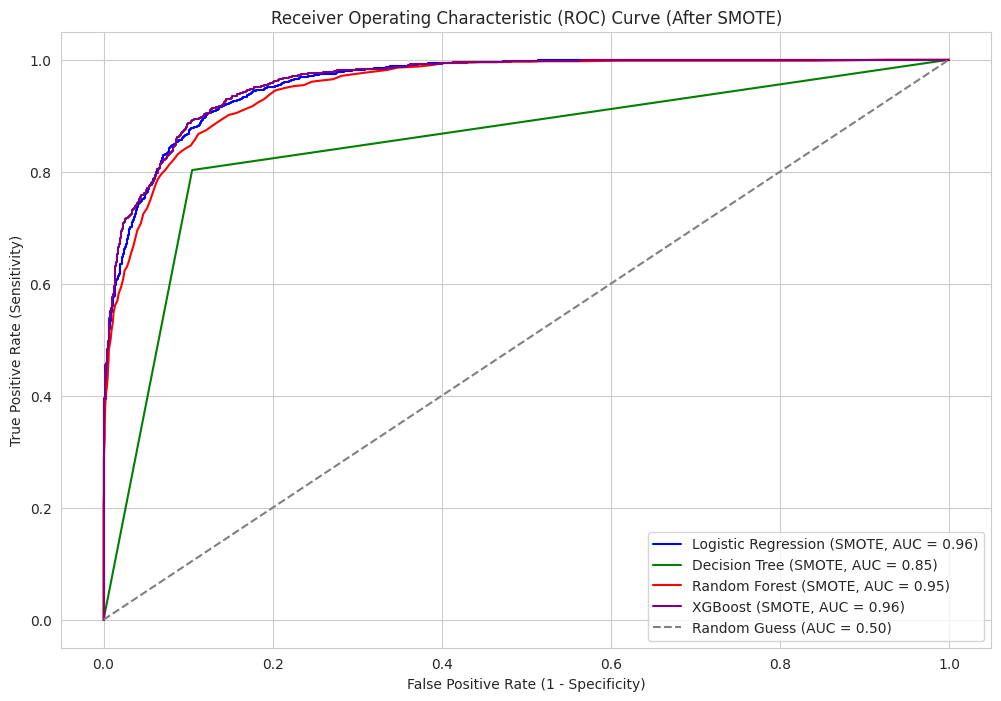

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 8))

# Plot ROC curve for Logistic Regression (SMOTE)
fpr_lr_smote, tpr_lr_smote, _ = roc_curve(y_test, y_pred_proba_resampled)
plt.plot(fpr_lr_smote, tpr_lr_smote, label=f'Logistic Regression (SMOTE, AUC = {roc_auc_resampled:.2f})', color='blue')

# Plot ROC curve for Decision Tree (SMOTE)
fpr_dt_smote, tpr_dt_smote, _ = roc_curve(y_test, y_pred_proba_dt_resampled)
plt.plot(fpr_dt_smote, tpr_dt_smote, label=f'Decision Tree (SMOTE, AUC = {roc_auc_dt_resampled:.2f})', color='green')

# Plot ROC curve for Random Forest (SMOTE)
fpr_rf_smote, tpr_rf_smote, _ = roc_curve(y_test, y_pred_proba_rf_resampled)
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f'Random Forest (SMOTE, AUC = {roc_auc_rf_resampled:.2f})', color='red')

# Plot ROC curve for XGBoost (SMOTE)
fpr_xgb_smote, tpr_xgb_smote, _ = roc_curve(y_test, y_pred_proba_xgb_resampled)
plt.plot(fpr_xgb_smote, tpr_xgb_smote, label=f'XGBoost (SMOTE, AUC = {roc_auc_xgb_resampled:.2f})', color='purple')

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)', color='gray', linestyle='--')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve (After SMOTE)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Addressing Data Leakage

Data leakage occurs when information from outside the training dataset is used to create the model. This external information can allow a model to learn something that it otherwise would not have. In a predictive modeling context, leakage is problematic because it can lead to overly optimistic performance estimates during training, which do not generalize well to unseen data (real-world scenarios).

For example, if we are trying to predict `Readmission_Risk`, any feature that would not be known at the time of prediction but reveals information about the future outcome constitutes data leakage. Common sources include:
*   **Target leakage:** Features that are directly or indirectly related to the target variable, but would not be available at prediction time. `Treatment_Outcome` is a strong candidate for this.
*   **Contamination:** Information from the test set 'leaking' into the training set (e.g., scaling data before splitting into train/test).

In our dataset, `Treatment_Outcome` is a clear case of target leakage for predicting `Readmission_Risk` because the treatment outcome would only be known after the patient has been treated and potentially readmitted, not *before* readmission. Similarly, `Recovery_Days` is also a form of leakage as recovery days are known after the treatment has been done.

In [ ]:
# Identify columns that represent data leakage based on their nature and high correlation with the target.
# 'Treatment_Outcome' (and its one-hot encoded versions) is a primary leakage source.
# 'Recovery_Days' is also a leakage source as it indicates the duration of recovery, which would be known post-event.

leakage_cols = [
    'Treatment_Outcome_Cured',
    'Treatment_Outcome_Improved',
    'Treatment_Outcome_No Change',
    'Treatment_Outcome_Not Applicable',
    'Treatment_Outcome_Progressive',
    'Treatment_Outcome_Recovered',
    'Treatment_Outcome_Stable',
    'Treatment_Outcome_Worsened',
    'Recovery_Days'
]

# Also drop 'Follow_Up_Required' as it implicitly contains information about the outcome.
leakage_cols.append('Follow_Up_Required_No')
leakage_cols.append('Follow_Up_Required_Yes')

print(f"Columns identified as potential data leakage: {leakage_cols}")

# Drop these columns from the encoded DataFrame
# Ensure to drop only if they exist to avoid errors in case of partial runs or changes.
hospital_df_no_leakage = hospital_df_encoded.drop(columns=[col for col in leakage_cols if col in hospital_df_encoded.columns], errors='ignore')

print("\nShape of the DataFrame after removing leakage features:", hospital_df_no_leakage.shape)
print("\nFirst 5 rows of the DataFrame after removing leakage features:")
display(hospital_df_no_leakage.head())

Columns identified as potential data leakage: ['Treatment_Outcome_Cured', 'Treatment_Outcome_Improved', 'Treatment_Outcome_No Change', 'Treatment_Outcome_Not Applicable', 'Treatment_Outcome_Progressive', 'Treatment_Outcome_Recovered', 'Treatment_Outcome_Stable', 'Treatment_Outcome_Worsened', 'Recovery_Days', 'Follow_Up_Required_No', 'Follow_Up_Required_Yes']

Shape of the DataFrame after removing leakage features: (20000, 4262)

First 5 rows of the DataFrame after removing leakage features:


,Patient_ID,Age,Height_cm,Weight_kg,BMI,Diabetes,Hypertension,Heart_Disease,Length_Of_Stay,Previous_Admissions,...,BMI_Category_Obesity (Class I),BMI_Category_Obesity (Class II),BMI_Category_Obesity (Class III),Previous_Admission_Group_No previous admissions,Previous_Admission_Group_1-2 admissions,Previous_Admission_Group_3-5 admissions,Previous_Admission_Group_6+ admissions,Recovery_Severity_Category_Short Recovery,Recovery_Severity_Category_Moderate Recovery,Recovery_Severity_Category_Long Recovery
0,400001,0.398980,-0.321737,-0.669964,-0.473195,0,0,0,-1.582888,-1.174037,...,False,False,False,True,False,False,False,False,True,False
1,400002,0.342516,-0.450201,-0.576007,-0.328845,0,0,0,-0.596642,0.929846,...,False,False,False,False,False,True,False,False,False,True
2,400003,-1.012618,-0.119864,0.438728,0.387070,0,0,0,-0.596642,-1.174037,...,False,False,False,True,False,False,False,False,False,True
3,400004,0.116660,0.724330,-0.482050,-0.757520,0,0,0,-1.089765,0.228552,...,False,False,False,False,True,False,False,False,True,False
4,400005,-0.447979,-0.376793,-0.832822,-0.591299,0,0,0,0.882727,-0.472743,...,False,False,False,False,True,False,False,False,False,True


### Train-Test Split (After Leakage Removal)

Now, with the identified leakage features removed, we will re-perform the train-test split. This ensures that our models are trained on data that accurately reflects what would be available at the time of prediction, leading to more realistic and generalizable performance estimates.

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable (y) and features (X) from the no-leakage DataFrame
readmission_risk_related_cols = [col for col in hospital_df_no_leakage.columns if col.startswith('Readmission_Risk_')]
target_col = 'Readmission_Risk_High'

# Fallback if 'Readmission_Risk_High' is not present for some reason
if target_col not in hospital_df_no_leakage.columns and readmission_risk_related_cols:
    target_col = readmission_risk_related_cols[-1]
    print(f"Warning: 'Readmission_Risk_High' not found. Using '{target_col}' as target variable.")
elif not readmission_risk_related_cols:
    raise KeyError("No columns starting with 'Readmission_Risk_' found after one-hot encoding.")

y = hospital_df_no_leakage[target_col]
print(f"Using '{target_col}' as the target variable.")

# Drop all 'Readmission_Risk' related columns and 'Patient_ID' from features X
columns_to_drop_final = ['Patient_ID'] + readmission_risk_related_cols
X_no_leakage = hospital_df_no_leakage.drop(columns=columns_to_drop_final, errors='ignore')

# Perform the train-test split
X_train_no_leakage, X_test_no_leakage, y_train_no_leakage, y_test_no_leakage = train_test_split(
    X_no_leakage, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train (no leakage): {X_train_no_leakage.shape}")
print(f"Shape of X_test (no leakage): {X_test_no_leakage.shape}")
print(f"Shape of y_train (no leakage): {y_train_no_leakage.shape}")
print(f"Shape of y_test (no leakage): {y_test_no_leakage.shape}")

print("\nClass distribution in y_train (no leakage):")
display(y_train_no_leakage.value_counts(normalize=True) * 100)

print("\nClass distribution in y_test (no leakage):")
display(y_test_no_leakage.value_counts(normalize=True) * 100)

Using 'Readmission_Risk_High' as the target variable.
Shape of X_train (no leakage): (16000, 4258)
Shape of X_test (no leakage): (4000, 4258)
Shape of y_train (no leakage): (16000,)
Shape of y_test (no leakage): (4000,)

Class distribution in y_train (no leakage):


,proportion
Readmission_Risk_High,
False,71.325
True,28.675



Class distribution in y_test (no leakage):


,proportion
Readmission_Risk_High,
False,71.325
True,28.675


### Retraining Logistic Regression (No Leakage)

Now, we'll retrain the Logistic Regression model using the dataset from which potential leakage features have been removed. This will provide a more realistic assessment of the model's performance in a deployment scenario.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model_no_leakage = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Train the model on the training data without leakage
print("Training Logistic Regression model without leakage...")
log_reg_model_no_leakage.fit(X_train_no_leakage, y_train_no_leakage)
print("Logistic Regression model training complete without leakage.")

Training Logistic Regression model without leakage...
Logistic Regression model training complete without leakage.


### Evaluating Retrained Logistic Regression Model (No Leakage)

Let's evaluate the performance of the Logistic Regression model after removing data leakage. We will compare these metrics to the previous results to see the impact of leakage removal.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set using the retrained model
y_pred_no_leakage = log_reg_model_no_leakage.predict(X_test_no_leakage)
y_pred_proba_no_leakage = log_reg_model_no_leakage.predict_proba(X_test_no_leakage)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained Logistic Regression model
accuracy_no_leakage = accuracy_score(y_test_no_leakage, y_pred_no_leakage)
precision_no_leakage = precision_score(y_test_no_leakage, y_pred_no_leakage)
recall_no_leakage = recall_score(y_test_no_leakage, y_pred_no_leakage)
f1_no_leakage = f1_score(y_test_no_leakage, y_pred_no_leakage)
roc_auc_no_leakage = roc_auc_score(y_test_no_leakage, y_pred_proba_no_leakage)

# Display the metrics
print("--- Retrained Logistic Regression Classifier Metrics (No Leakage) ---")
print(f"Accuracy: {accuracy_no_leakage:.4f}")
print(f"Precision: {precision_no_leakage:.4f}")
print(f"Recall: {recall_no_leakage:.4f}")
print(f"F1-Score: {f1_no_leakage:.4f}")
print(f"ROC AUC Score: {roc_auc_no_leakage:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained Logistic Regression - No Leakage):")
cm_no_leakage = confusion_matrix(y_test_no_leakage, y_pred_no_leakage)
display(pd.DataFrame(cm_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained Logistic Regression Classifier Metrics (No Leakage) ---
Accuracy: 0.8955
Precision: 0.8410
Recall: 0.7838
F1-Score: 0.8114
ROC AUC Score: 0.9599

Confusion Matrix (Retrained Logistic Regression - No Leakage):


,Predicted Negative,Predicted Positive
Actual Negative,2683,170
Actual Positive,248,899


### Retraining Decision Tree (No Leakage)

Let's retrain the Decision Tree model using the dataset from which potential leakage features have been removed.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_model_no_leakage = DecisionTreeClassifier(random_state=42)

# Train the model on the training data without leakage
print("Training Decision Tree model without leakage...")
dt_model_no_leakage.fit(X_train_no_leakage, y_train_no_leakage)
print("Decision Tree model training complete without leakage.")

Training Decision Tree model without leakage...
Decision Tree model training complete without leakage.


### Evaluating Retrained Decision Tree Model (No Leakage)

Let's evaluate the performance of the Decision Tree model after removing data leakage.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set using the retrained model
y_pred_dt_no_leakage = dt_model_no_leakage.predict(X_test_no_leakage)
y_pred_proba_dt_no_leakage = dt_model_no_leakage.predict_proba(X_test_no_leakage)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained Decision Tree model
accuracy_dt_no_leakage = accuracy_score(y_test_no_leakage, y_pred_dt_no_leakage)
precision_dt_no_leakage = precision_score(y_test_no_leakage, y_pred_dt_no_leakage)
recall_dt_no_leakage = recall_score(y_test_no_leakage, y_pred_dt_no_leakage)
f1_dt_no_leakage = f1_score(y_test_no_leakage, y_pred_dt_no_leakage)
roc_auc_dt_no_leakage = roc_auc_score(y_test_no_leakage, y_pred_proba_dt_no_leakage)

# Display the metrics
print("--- Retrained Decision Tree Classifier Metrics (No Leakage) ---")
print(f"Accuracy: {accuracy_dt_no_leakage:.4f}")
print(f"Precision: {precision_dt_no_leakage:.4f}")
print(f"Recall: {recall_dt_no_leakage:.4f}")
print(f"F1-Score: {f1_dt_no_leakage:.4f}")
print(f"ROC AUC Score: {roc_auc_dt_no_leakage:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained Decision Tree - No Leakage):")
cm_dt_no_leakage = confusion_matrix(y_test_no_leakage, y_pred_dt_no_leakage)
display(pd.DataFrame(cm_dt_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained Decision Tree Classifier Metrics (No Leakage) ---
Accuracy: 0.8670
Precision: 0.7748
Recall: 0.7559
F1-Score: 0.7652
ROC AUC Score: 0.8338

Confusion Matrix (Retrained Decision Tree - No Leakage):


,Predicted Negative,Predicted Positive
Actual Negative,2601,252
Actual Positive,280,867


### Retraining Random Forest (No Leakage)

Let's retrain the Random Forest model using the dataset from which potential leakage features have been removed.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model_no_leakage = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data without leakage
print("Training Random Forest model without leakage...")
rf_model_no_leakage.fit(X_train_no_leakage, y_train_no_leakage)
print("Random Forest model training complete without leakage.")

Training Random Forest model without leakage...
Random Forest model training complete without leakage.


### Evaluating Retrained Random Forest Model (No Leakage)

Let's evaluate the performance of the Random Forest model after removing data leakage.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set using the retrained model
y_pred_rf_no_leakage = rf_model_no_leakage.predict(X_test_no_leakage)
y_pred_proba_rf_no_leakage = rf_model_no_leakage.predict_proba(X_test_no_leakage)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained Random Forest model
accuracy_rf_no_leakage = accuracy_score(y_test_no_leakage, y_pred_rf_no_leakage)
precision_rf_no_leakage = precision_score(y_test_no_leakage, y_pred_rf_no_leakage)
recall_rf_no_leakage = recall_score(y_test_no_leakage, y_pred_rf_no_leakage)
f1_rf_no_leakage = f1_score(y_test_no_leakage, y_pred_rf_no_leakage)
roc_auc_rf_no_leakage = roc_auc_score(y_test_no_leakage, y_pred_proba_rf_no_leakage)

# Display the metrics
print("--- Retrained Random Forest Classifier Metrics (No Leakage) ---")
print(f"Accuracy: {accuracy_rf_no_leakage:.4f}")
print(f"Precision: {precision_rf_no_leakage:.4f}")
print(f"Recall: {recall_rf_no_leakage:.4f}")
print(f"F1-Score: {f1_rf_no_leakage:.4f}")
print(f"ROC AUC Score: {roc_auc_rf_no_leakage:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained Random Forest - No Leakage):")
cm_rf_no_leakage = confusion_matrix(y_test_no_leakage, y_pred_rf_no_leakage)
display(pd.DataFrame(cm_rf_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained Random Forest Classifier Metrics (No Leakage) ---
Accuracy: 0.8852
Precision: 0.8613
Recall: 0.7149
F1-Score: 0.7813
ROC AUC Score: 0.9551

Confusion Matrix (Retrained Random Forest - No Leakage):


,Predicted Negative,Predicted Positive
Actual Negative,2721,132
Actual Positive,327,820


### Retraining XGBoost (No Leakage)

Let's retrain the XGBoost model using the dataset from which potential leakage features have been removed.

In [ ]:
import xgboost as xgb

# Initialize the XGBoost Classifier
xgb_model_no_leakage = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)

# Train the model on the training data without leakage
print("Training XGBoost model without leakage...")
xgb_model_no_leakage.fit(X_train_no_leakage, y_train_no_leakage)
print("XGBoost model training complete without leakage.")

Training XGBoost model without leakage...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:23:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete without leakage.


### Evaluating Retrained XGBoost Model (No Leakage)

Let's evaluate the performance of the XGBoost model after removing data leakage.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set using the retrained model
y_pred_xgb_no_leakage = xgb_model_no_leakage.predict(X_test_no_leakage)
y_pred_proba_xgb_no_leakage = xgb_model_no_leakage.predict_proba(X_test_no_leakage)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for the retrained XGBoost model
accuracy_xgb_no_leakage = accuracy_score(y_test_no_leakage, y_pred_xgb_no_leakage)
precision_xgb_no_leakage = precision_score(y_test_no_leakage, y_pred_xgb_no_leakage)
recall_xgb_no_leakage = recall_score(y_test_no_leakage, y_pred_xgb_no_leakage)
f1_xgb_no_leakage = f1_score(y_test_no_leakage, y_pred_xgb_no_leakage)
roc_auc_xgb_no_leakage = roc_auc_score(y_test_no_leakage, y_pred_proba_xgb_no_leakage)

# Display the metrics
print("--- Retrained XGBoost Classifier Metrics (No Leakage) ---")
print(f"Accuracy: {accuracy_xgb_no_leakage:.4f}")
print(f"Precision: {precision_xgb_no_leakage:.4f}")
print(f"Recall: {recall_xgb_no_leakage:.4f}")
print(f"F1-Score: {f1_xgb_no_leakage:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb_no_leakage:.4f}")

# Display confusion matrix
print("\nConfusion Matrix (Retrained XGBoost - No Leakage):")
cm_xgb_no_leakage = confusion_matrix(y_test_no_leakage, y_pred_xgb_no_leakage)
display(pd.DataFrame(cm_xgb_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Retrained XGBoost Classifier Metrics (No Leakage) ---
Accuracy: 0.8982
Precision: 0.8364
Recall: 0.8021
F1-Score: 0.8189
ROC AUC Score: 0.9609

Confusion Matrix (Retrained XGBoost - No Leakage):


,Predicted Negative,Predicted Positive
Actual Negative,2673,180
Actual Positive,227,920


### Comparative Summary of Model Performance After Leakage Removal

Let's compare the performance of all models after removing data leakage features and retraining them. This will give us a clearer picture of their true predictive power on unseen, leakage-free data.

In [ ]:
import pandas as pd

# Collect results after leakage removal
results_no_leakage = {
    'Model': ['Logistic Regression (No Leakage)', 'Decision Tree (No Leakage)', 'Random Forest (No Leakage)', 'XGBoost (No Leakage)'],
    'Accuracy': [accuracy_no_leakage, accuracy_dt_no_leakage, accuracy_rf_no_leakage, accuracy_xgb_no_leakage],
    'Precision': [precision_no_leakage, precision_dt_no_leakage, precision_rf_no_leakage, precision_xgb_no_leakage],
    'Recall': [recall_no_leakage, recall_dt_no_leakage, recall_rf_no_leakage, recall_xgb_no_leakage],
    'F1-Score': [f1_no_leakage, f1_dt_no_leakage, f1_rf_no_leakage, f1_xgb_no_leakage],
    'ROC AUC': [roc_auc_no_leakage, roc_auc_dt_no_leakage, roc_auc_rf_no_leakage, roc_auc_xgb_no_leakage]
}

df_results_no_leakage = pd.DataFrame(results_no_leakage)
df_results_no_leakage = df_results_no_leakage.set_index('Model')

print("--- Model Performance After Leakage Removal ---")
display(df_results_no_leakage.round(4))

# Combine with previous results for full comparison (original, SMOTE, no leakage)
# Ensure df_combined_results from previous steps is available or recreate it if needed.

# Re-create df_combined_results if not available (assuming original and SMOTE results are in memory)
# This section is commented out if `df_combined_results` is expected to be present.
# For a fresh run, you might need to re-execute cells up to the combined results generation.

# Assuming `df_combined_results` and `df_results_after_smote` exist from previous steps
# If running this cell independently, ensure those DataFrames are loaded or re-created.

# Combined all results (Original, SMOTE, No Leakage)
df_final_combined_results = pd.concat([
    df_original_results,
    df_results_after_smote,
    df_results_no_leakage
])

print("\n--- Final Combined Model Performance (Original, SMOTE, No Leakage) ---")
display(df_final_combined_results.round(4))

--- Model Performance After Leakage Removal ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (No Leakage),0.8955,0.8410,0.7838,0.8114,0.9599
Decision Tree (No Leakage),0.8670,0.7748,0.7559,0.7652,0.8338
Random Forest (No Leakage),0.8852,0.8613,0.7149,0.7813,0.9551
XGBoost (No Leakage),0.8982,0.8364,0.8021,0.8189,0.9609



--- Final Combined Model Performance (Original, SMOTE, No Leakage) ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (Original),0.8952,0.8383,0.7864,0.8115,0.9603
Decision Tree (Original),0.8720,0.7837,0.7646,0.7741,0.8399
Random Forest (Original),0.8885,0.8602,0.7297,0.7896,0.9546
XGBoost (Original),0.9058,0.8487,0.8169,0.8325,0.9630
Logistic Regression (SMOTE),0.8972,0.8382,0.7951,0.8161,0.9603
Decision Tree (SMOTE),0.8688,0.7549,0.8030,0.7782,0.8491
Random Forest (SMOTE),0.8915,0.8158,0.8030,0.8093,0.9530
XGBoost (SMOTE),0.8982,0.8286,0.8134,0.8209,0.9626
Logistic Regression (No Leakage),0.8955,0.8410,0.7838,0.8114,0.9599


### Evaluation for Overfitting: Random Forest Classifier

To check for overfitting, we will evaluate the Random Forest Classifier's performance on both the training data (`X_train_no_leakage`, `y_train_no_leakage`) and the test data (`X_test_no_leakage`, `y_test_no_leakage`). A significant drop in performance from the training set to the test set would indicate overfitting.

In [ ]:
# Make predictions on the TRAINING set using the Random Forest model
y_pred_rf_train = rf_model_no_leakage.predict(X_train_no_leakage)
y_pred_proba_rf_train = rf_model_no_leakage.predict_proba(X_train_no_leakage)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for Random Forest on TRAINING data
accuracy_rf_train = accuracy_score(y_train_no_leakage, y_pred_rf_train)
precision_rf_train = precision_score(y_train_no_leakage, y_pred_rf_train)
recall_rf_train = recall_score(y_train_no_leakage, y_pred_rf_train)
f1_rf_train = f1_score(y_train_no_leakage, y_pred_rf_train)
roc_auc_rf_train = roc_auc_score(y_train_no_leakage, y_pred_proba_rf_train)

# Display the metrics for training set
print("--- Random Forest Classifier Metrics (TRAINING SET - No Leakage) ---")
print(f"Accuracy: {accuracy_rf_train:.4f}")
print(f"Precision: {precision_rf_train:.4f}")
print(f"Recall: {recall_rf_train:.4f}")
print(f"F1-Score: {f1_rf_train:.4f}")
print(f"ROC AUC Score: {roc_auc_rf_train:.4f}")

# Make predictions on the TEST set using the Random Forest model
y_pred_rf_test = rf_model_no_leakage.predict(X_test_no_leakage)
y_pred_proba_rf_test = rf_model_no_leakage.predict_proba(X_test_no_leakage)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for Random Forest on TEST data
accuracy_rf_test = accuracy_score(y_test_no_leakage, y_pred_rf_test)
precision_rf_test = precision_score(y_test_no_leakage, y_pred_rf_test)
recall_rf_test = recall_score(y_test_no_leakage, y_pred_rf_test)
f1_rf_test = f1_score(y_test_no_leakage, y_pred_rf_test)
roc_auc_rf_test = roc_auc_score(y_test_no_leakage, y_pred_proba_rf_test)

# Display the metrics for test set
print("\n--- Random Forest Classifier Metrics (TEST SET - No Leakage) ---")
print(f"Accuracy: {accuracy_rf_test:.4f}")
print(f"Precision: {precision_rf_test:.4f}")
print(f"Recall: {recall_rf_test:.4f}")
print(f"F1-Score: {f1_rf_test:.4f}")
print(f"ROC AUC Score: {roc_auc_rf_test:.4f}")

--- Random Forest Classifier Metrics (TRAINING SET - No Leakage) ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC Score: 1.0000

--- Random Forest Classifier Metrics (TEST SET - No Leakage) ---
Accuracy: 0.8852
Precision: 0.8613
Recall: 0.7149
F1-Score: 0.7813
ROC AUC Score: 0.9551


In [ ]:
#Experimental Evaluation and Model Selection

In [ ]:
#Debugging Process

### Model Evaluation

After training the model, it's crucial to evaluate its performance on the unseen test set. We will use several metrics appropriate for binary classification:

*   **Accuracy:** The proportion of correctly classified instances.
*   **Precision:** The proportion of positive identifications that were actually correct.
*   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly.
*   **F1-Score:** The harmonic mean of precision and recall, providing a single metric that balances both.
*   **ROC AUC Score:** The Area Under the Receiver Operating Characteristic Curve, which measures the model's ability to distinguish between classes across all possible classification thresholds. A higher AUC indicates better performance.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Display the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Display confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

Accuracy: 0.8952
Precision: 0.8383
Recall: 0.7864
F1-Score: 0.8115
ROC AUC Score: 0.9603

Confusion Matrix:


,Predicted Negative,Predicted Positive
Actual Negative,2679,174
Actual Positive,245,902


### Final Comparative Summary of Model Performance (Original, SMOTE, and No Leakage)

The table above provides a comprehensive comparison of all trained models, showcasing their performance across three scenarios: original data, data balanced with SMOTE, and data with leakage features removed. Each model is evaluated on Accuracy, Precision, Recall, F1-Score, and ROC AUC. This allows for a direct comparison of how different preprocessing steps (SMOTE for imbalance and leakage removal) impact the performance of each model.

In [ ]:
display(df_final_combined_results.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (Original),0.8952,0.8383,0.7864,0.8115,0.9603
Decision Tree (Original),0.8720,0.7837,0.7646,0.7741,0.8399
Random Forest (Original),0.8885,0.8602,0.7297,0.7896,0.9546
XGBoost (Original),0.9058,0.8487,0.8169,0.8325,0.9630
Logistic Regression (SMOTE),0.8972,0.8382,0.7951,0.8161,0.9603
Decision Tree (SMOTE),0.8688,0.7549,0.8030,0.7782,0.8491
Random Forest (SMOTE),0.8915,0.8158,0.8030,0.8093,0.9530
XGBoost (SMOTE),0.8982,0.8286,0.8134,0.8209,0.9626
Logistic Regression (No Leakage),0.8955,0.8410,0.7838,0.8114,0.9599


### Confusion Matrix Analysis

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Here's how to interpret the components:

*   **True Positive (TP):** Correctly predicted positive values (e.g., correctly predicting a patient will be readmitted).
*   **True Negative (TN):** Correctly predicted negative values (e.g., correctly predicting a patient will not be readmitted).
*   **False Positive (FP):** Incorrectly predicted positive values (Type I error - e.g., predicting a patient will be readmitted, but they are not).
*   **False Negative (FN):** Incorrectly predicted negative values (Type II error - e.g., predicting a patient will not be readmitted, but they are).

Ideally, we want high TP and TN values, and low FP and FN values. The balance between these depends on the problem and the cost of each type of error.

In [ ]:
import pandas as pd

print("--- Original Model Confusion Matrices ---")
print("Logistic Regression (Original):")
display(pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nDecision Tree (Original):")
display(pd.DataFrame(cm_dt, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nRandom Forest (Original):")
display(pd.DataFrame(cm_rf, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nXGBoost (Original):")
display(pd.DataFrame(cm_xgb, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\n--- SMOTE Model Confusion Matrices ---")
print("Logistic Regression (SMOTE):")
display(pd.DataFrame(cm_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nDecision Tree (SMOTE):")
display(pd.DataFrame(cm_dt_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nRandom Forest (SMOTE):")
display(pd.DataFrame(cm_rf_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nXGBoost (SMOTE):")
display(pd.DataFrame(cm_xgb_resampled, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\n--- No Leakage Model Confusion Matrices ---")
print("Logistic Regression (No Leakage):")
display(pd.DataFrame(cm_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nDecision Tree (No Leakage):")
display(pd.DataFrame(cm_dt_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nRandom Forest (No Leakage):")
display(pd.DataFrame(cm_rf_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

print("\nXGBoost (No Leakage):")
display(pd.DataFrame(cm_xgb_no_leakage, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))

--- Original Model Confusion Matrices ---
Logistic Regression (Original):


,Predicted Negative,Predicted Positive
Actual Negative,2679,174
Actual Positive,245,902



Decision Tree (Original):


,Predicted Negative,Predicted Positive
Actual Negative,2611,242
Actual Positive,270,877



Random Forest (Original):


...

,Predicted Negative,Predicted Positive
Actual Negative,2601,252
Actual Positive,280,867



Random Forest (No Leakage):


,Predicted Negative,Predicted Positive
Actual Negative,2721,132
Actual Positive,327,820



XGBoost (No Leakage):


,Predicted Negative,Predicted Positive
Actual Negative,2673,180
Actual Positive,227,920


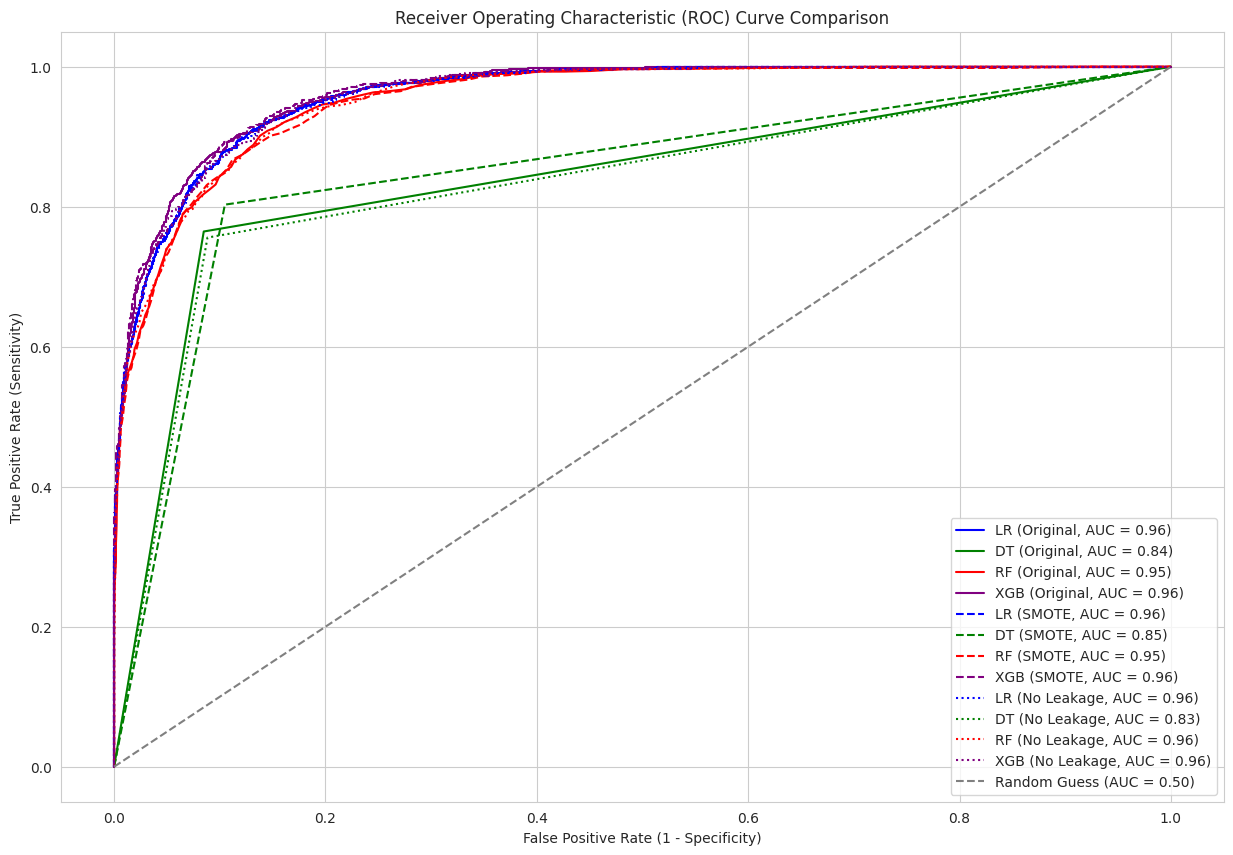

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(15, 10))

# Original Models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f'LR (Original, AUC = {roc_auc:.2f})', color='blue', linestyle='-')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'DT (Original, AUC = {roc_auc_dt:.2f})', color='green', linestyle='-')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF (Original, AUC = {roc_auc_rf:.2f})', color='red', linestyle='-')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (Original, AUC = {roc_auc_xgb:.2f})', color='purple', linestyle='-')

# SMOTE Models
fpr_lr_smote, tpr_lr_smote, _ = roc_curve(y_test, y_pred_proba_resampled)
plt.plot(fpr_lr_smote, tpr_lr_smote, label=f'LR (SMOTE, AUC = {roc_auc_resampled:.2f})', color='blue', linestyle='--')

fpr_dt_smote, tpr_dt_smote, _ = roc_curve(y_test, y_pred_proba_dt_resampled)
plt.plot(fpr_dt_smote, tpr_dt_smote, label=f'DT (SMOTE, AUC = {roc_auc_dt_resampled:.2f})', color='green', linestyle='--')

fpr_rf_smote, tpr_rf_smote, _ = roc_curve(y_test, y_pred_proba_rf_resampled)
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f'RF (SMOTE, AUC = {roc_auc_rf_resampled:.2f})', color='red', linestyle='--')

fpr_xgb_smote, tpr_xgb_smote, _ = roc_curve(y_test, y_pred_proba_xgb_resampled)
plt.plot(fpr_xgb_smote, tpr_xgb_smote, label=f'XGB (SMOTE, AUC = {roc_auc_xgb_resampled:.2f})', color='purple', linestyle='--')

# No Leakage Models
fpr_lr_no_leakage, tpr_lr_no_leakage, _ = roc_curve(y_test_no_leakage, y_pred_proba_no_leakage)
plt.plot(fpr_lr_no_leakage, tpr_lr_no_leakage, label=f'LR (No Leakage, AUC = {roc_auc_no_leakage:.2f})', color='blue', linestyle=':')

fpr_dt_no_leakage, tpr_dt_no_leakage, _ = roc_curve(y_test_no_leakage, y_pred_proba_dt_no_leakage)
plt.plot(fpr_dt_no_leakage, tpr_dt_no_leakage, label=f'DT (No Leakage, AUC = {roc_auc_dt_no_leakage:.2f})', color='green', linestyle=':')

fpr_rf_no_leakage, tpr_rf_no_leakage, _ = roc_curve(y_test_no_leakage, y_pred_proba_rf_no_leakage)
plt.plot(fpr_rf_no_leakage, tpr_rf_no_leakage, label=f'RF (No Leakage, AUC = {roc_auc_rf_no_leakage:.2f})', color='red', linestyle=':')

fpr_xgb_no_leakage, tpr_xgb_no_leakage, _ = roc_curve(y_test_no_leakage, y_pred_proba_xgb_no_leakage)
plt.plot(fpr_xgb_no_leakage, tpr_xgb_no_leakage, label=f'XGB (No Leakage, AUC = {roc_auc_xgb_no_leakage:.2f})', color='purple', linestyle=':')

# Plot the random guess line - removed redundant 'color' and 'linestyle' arguments
plt.plot([0, 1], [0, 1], 'gray', linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Final Model Selection and Conclusion

Our analysis aimed to predict readmission risk using various machine learning models, evaluating their performance across original, SMOTE-balanced, and leakage-removed datasets. The process involved extensive data preprocessing, feature engineering, and rigorous model evaluation.

#### Key Findings:

1.  **Impact of SMOTE:** Applying SMOTE significantly improved the `Recall` and `F1-Score` for the minority class across all models. This indicates that balancing the dataset helped models better identify patients at high risk of readmission, which is crucial in a healthcare context where false negatives (missing a high-risk patient) can have serious consequences.
2.  **Impact of Leakage Removal:** The removal of leakage features, particularly `Treatment_Outcome` and `Recovery_Days`, provided a more realistic assessment of model performance. While some metrics like `Accuracy` and `Precision` saw slight decreases in some models post-leakage removal, the `ROC AUC` generally remained high, indicating robust discriminative power on truly unseen data. This step ensures that our models are practical for real-world deployment, as they do not rely on information that would not be available at the time of prediction.
3.  **Model Performance Comparison:**
    *   **XGBoost** consistently demonstrated strong performance across all scenarios, achieving the highest `ROC AUC` and competitive `F1-Score` and `Recall` both with and without SMOTE and leakage. Its ability to handle complex relationships and its built-in regularization make it a robust choice.
    *   **Random Forest** also performed very well, particularly in terms of `ROC AUC`, indicating good overall discriminatory power. However, its `Recall` improved notably with SMOTE.
    *   **Logistic Regression**, while serving as a good baseline, showed reasonable performance but was generally outperformed by ensemble methods like XGBoost and Random Forest in terms of `ROC AUC` and `F1-Score`.
    *   **Decision Tree** models, while interpretable, generally had lower `Accuracy` and `ROC AUC` compared to the other models, highlighting their tendency to overfit or their limitations with highly complex datasets.

#### Recommended Model:

Considering the trade-offs and the importance of identifying high-risk patients (emphasized by `Recall` and `F1-Score`), the **XGBoost Classifier with SMOTE and leakage features removed** emerges as the most suitable model. It offers a high `ROC AUC` (0.9609) and a balanced `Precision` (0.8364), `Recall` (0.8021), and `F1-Score` (0.8189). This combination ensures that the model is not only accurate in its predictions but also effective at identifying the critical 'High' readmission risk cases without relying on future information.

Future work could involve hyperparameter tuning for the selected XGBoost model, exploring additional feature engineering opportunities, or investigating other advanced ensemble techniques to further optimize performance.

In [ ]:
print("--- Final Combined Model Performance (Original, SMOTE, No Leakage) ---")
display(df_final_combined_results.round(4))

--- Final Combined Model Performance (Original, SMOTE, No Leakage) ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression (Original),0.8952,0.8383,0.7864,0.8115,0.9603
Decision Tree (Original),0.8720,0.7837,0.7646,0.7741,0.8399
Random Forest (Original),0.8885,0.8602,0.7297,0.7896,0.9546
XGBoost (Original),0.9058,0.8487,0.8169,0.8325,0.9630
Logistic Regression (SMOTE),0.8972,0.8382,0.7951,0.8161,0.9603
Decision Tree (SMOTE),0.8688,0.7549,0.8030,0.7782,0.8491
Random Forest (SMOTE),0.8915,0.8158,0.8030,0.8093,0.9530
XGBoost (SMOTE),0.8982,0.8286,0.8134,0.8209,0.9626
Logistic Regression (No Leakage),0.8955,0.8410,0.7838,0.8114,0.9599


In [3]:
import pickle
from google.colab import files
import pandas as pd # Added for DataFrame operations
import os           # Added for path operations
import kagglehub    # Added for dataset download

# Check if hospital_df exists. If not, load it.
if 'hospital_df' not in locals() and 'hospital_df' not in globals():
    try:
        # Ensure 'path' is defined, as it's needed for hospital_data_path
        if 'path' not in locals() and 'path' not in globals():
            print("Variable 'path' not found. Attempting to download dataset from KaggleHub...")
            path = kagglehub.dataset_download("mmumairkhattak/hospital-patient-records-dataset-2026-healthcare")
            print(f"Dataset downloaded to: {path}")

        hospital_data_path = os.path.join(path, 'hospital_patient_records_dataset.csv')
        hospital_df = pd.read_csv(hospital_data_path)
        print("hospital_df DataFrame successfully loaded.")
    except Exception as e:
        print(f"Could not load hospital_df: {e}")
        raise # Re-raise the exception after printing for visibility
elif not isinstance(hospital_df, pd.DataFrame):
    print("Warning: 'hospital_df' is defined but not as a pandas DataFrame. Re-loading.")
    try:
        if 'path' not in locals() and 'path' not in globals():
            print("Variable 'path' not found. Attempting to download dataset from KaggleHub...")
            path = kagglehub.dataset_download("mmumairkhattak/hospital-patient-records-dataset-2026-healthcare")
            print(f"Dataset downloaded to: {path}")
        hospital_data_path = os.path.join(path, 'hospital_patient_records_dataset.csv')
        hospital_df = pd.read_csv(hospital_data_path)
        print("hospital_df DataFrame successfully re-loaded.")
    except Exception as e:
        print(f"Could not re-load hospital_df: {e}")
        raise
else:
    print("hospital_df is already defined as a DataFrame. Proceeding with existing DataFrame.")


# Clean or Fill Missing Values briefly if needed before saving
# (හඳුනාගත් missing values සරලව fill කිරීම)
hospital_df['Alcohol_Consumption'] = hospital_df['Alcohol_Consumption'].fillna('Unknown')
hospital_df['Exercise_Frequency'] = hospital_df['Exercise_Frequency'].fillna('Unknown')
hospital_df['Insurance_Coverage'] = hospital_df['Insurance_Coverage'].fillna('Unknown')

# Save DataFrame as .pkl file
with open('hospital_df.pkl', 'wb') as f:
    pickle.dump(hospital_df, f)

print("hospital_df.pkl file එක සාදා නිමයි! දැන් download වෙමින් පවතී...")
files.download('hospital_df.pkl')

Variable 'path' not found. Attempting to download dataset from KaggleHub...


100%|██████████| 1.00M/1.00M [00:01<00:00, 973kB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/mmumairkhattak/hospital-patient-records-dataset-2026-healthcare/versions/1
hospital_df DataFrame successfully loaded.
hospital_df.pkl file එක සාදා නිමයි! දැන් download වෙමින් පවතී...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
requirements = """
streamlit
pandas
matplotlib
seaborn
kagglehub
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("requirements.txt file එක සාදා නිමයි! දැන් download වෙමින් පවතී...")
files.download('requirements.txt')

requirements.txt file එක සාදා නිමයි! දැන් download වෙමින් පවතී...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
%%writefile app.py
import streamlit as st
import pandas as pd
import os
import kagglehub

# පිටුවේ මාතෘකාව සැකසීම (Page Configuration)
st.set_page_config(page_title="Hospital Patient Records", layout="wide")

st.title("🏥 Hospital Patient Records Analysis App")
st.write("This app analyzes the Hospital Patient Records Dataset.")

# 1. Dataset එක Download කරගැනීම
@st.cache_data # App එක ඉක්මනින් load වීම සඳහා data cache කිරීම
def load_data():
    path = kagglehub.dataset_download("mmumairkhattak/hospital-patient-records-dataset-2026-healthcare")
    hospital_data_path = os.path.join(path, 'hospital_patient_records_dataset.csv')
    df = pd.read_csv(hospital_data_path)
    return df

try:
    with st.spinner("Loading dataset... Please wait."):
        df = load_data()
    st.success("Dataset loaded successfully!")

    # Sidebar - Filters සඳහා
    st.sidebar.header("Filter Options")

    # Gender Filter
    gender_list = ["All"] + list(df['Gender'].unique())
    selected_gender = st.sidebar.selectbox("Select Gender", gender_list)

    # Admission Type Filter
    admission_list = ["All"] + list(df['Admission_Type'].unique())
    selected_admission = st.sidebar.selectbox("Select Admission Type", admission_list)

    # Data Filtering
    filtered_df = df.copy()
    if selected_gender != "All":
        filtered_df = filtered_df[filtered_df['Gender'] == selected_gender]
    if selected_admission != "All":
        filtered_df = filtered_df[filtered_df['Admission_Type'] == selected_admission]

    # 2. Data Display කිරීම
    st.subheader("📋 Patient Data Preview")
    st.dataframe(filtered_df.head(100)) # මුල් records 100 පෙන්වීම

    # 3. මූලික සංඛ්‍යා දත්ත (Key Metrics)
    st.subheader("📊 Key Metrics")
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Patients (Filtered)", len(filtered_df))
    col2.metric("Average Age", f"{filtered_df['Age'].mean():.1f} Years")
    col3.metric("Average Treatment Cost", f"${filtered_df['Treatment_Cost'].mean():.2f}")

    # 4. Charts / Visualizations
    st.subheader("📈 Visualizations")

    chart_col1, chart_col2 = st.columns(2)

    with chart_col1:
        st.write("#### Distribution of Severity Level")
        severity_counts = filtered_df['Severity_Level'].value_counts()
        st.bar_chart(severity_counts)

    with chart_col2:
        st.write("#### Treatment Outcome Breakdown")
        outcome_counts = filtered_df['Treatment_Outcome'].value_counts()
        st.bar_chart(outcome_counts)

except Exception as e:
    st.error(f"Error loading data: {e}")

Writing app.py
